# IPL Cricket Analytics - Player & Match Insights (2008–2024)
### A Data Analyst Portfolio Project

## Project Overview

```
Attribute and Detail
Domain** : Sports Analytics
Dataset** : IPL Ball-by-Ball Data 2008–2024 
Source** : Kaggle — IPL Dataset (matches.csv + deliveries.csv) 
Rows** : ~260,920 (deliveries) + ~1,095 (matches) 
Columns** : 17 (deliveries) + 20 (matches) 
Tools Used** : Python, Pandas, NumPy, Matplotlib, Seaborn 
```

## Business Problem Statement

**Industry:** Professional Sports - Indian Premier League (Cricket)

**The Problem:**  
IPL franchise owners spend **crores of rupees** every year at player auctions, often based on reputation, past league records, or gut instinct rather than structured data. There is very little visibility into:
- Which players genuinely perform when it matters most (playoffs vs. regular season)
- Which venues favour batting or bowling - and whether that should change team composition
- Whether winning the toss actually translates into winning the match
- Which team phases (powerplay, middle, death) are each franchise's weak points

**What decision needs to be made?**  
*A sports analytics firm advising IPL franchise owners needs to answer: *"Who should we buy at the auction, and how should we build our XI for each specific venue?"*

**What happens if this is NOT solved?**  
Franchises continue overpaying for players based on brand value, ignoring contextual performance. Teams with weaker analytical capabilities consistently lose to better-prepared opponents — and investors lose money.


## Dataset Description

- **deliveries.csv** — Ball-by-ball data: ~260,920 rows covering every delivery bowled across 17 IPL seasons
- **matches.csv** — Match metadata: ~1,095 rows covering match results, venues, toss decisions, player of match
- **Time Range:** 2008 – 2024 (Season 1 to Season 17)
- **Data Quality Issues Found:**
  - Team name inconsistencies (e.g., 'Delhi Daredevils' vs 'Delhi Capitals')
  - Super over deliveries (inning > 2) mixed with regular innings data
  - ~95% of extras_type is null (expected - most deliveries are normal balls)
  - ~5 matches with no result (abandoned/tied - no winner recorded)
  - Mixed season format: '2007/08', '2009', '2020/21' - needs normalisation


## Analytical Approach (steps)

```
Step 1: Data Loading & First Look
Step 2: Data Merging (join deliveries + matches on match_id)
Step 3: Data Cleaning (team names, super overs, null handling)
Step 4: Feature Engineering (strike rate, economy, phase labels)
Step 5: Batting Analysis (top batsmen, orange cap, averages)
Step 6: Bowling Analysis (top bowlers, purple cap, economy)
Step 7: Team & Venue Analysis (win %, toss impact, venue patterns)
Step 8: Advanced Analysis (partnerships, phase-wise, clutch factor)
Step 9: Unique Insight — Clutch Factor Index
```


## Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 50)

print("All libraries imported successfully.")
print(f"   Pandas version  : {pd.__version__}")
print(f"   NumPy version   : {np.__version__}")


All libraries imported successfully.
   Pandas version  : 2.3.3
   NumPy version   : 2.3.5


In [6]:
import os

# Create a folder to hold all CSV exports for the SQL layer
# This keeps everything organised in one place
output_folder = 'ipl_sql_data'
os.makedirs(output_folder, exist_ok=True)

print(f"Output folder ready: {os.path.abspath(output_folder)}")
print("All cleaned CSVs will be saved here for MySQL import.")

Output folder ready: C:\Users\hp\batch 367\AI framed Interview Questions\Resume Projects\data analytics\project 4 ipl\ipl\ipl analysis\ipl_sql_data
All cleaned CSVs will be saved here for MySQL import.


## Loading the Datasets

In [7]:
# deliveries.csv
deliveries = pd.read_csv('deliveries.csv')

# matches.csv 
matches = pd.read_csv('matches.csv')

print(f"deliveries.csv  -> {deliveries.shape[0]} rows, {deliveries.shape[1]} columns")
print(f"matches.csv     -> {matches.shape[0]} rows, {matches.shape[1]} columns")


deliveries.csv  -> 260920 rows, 17 columns
matches.csv     -> 1095 rows, 20 columns


In [8]:
print("Deliveris :- First 5 rows")
deliveries.head()


Deliveris :- First 5 rows


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [9]:
print("Matches :- First 5 rows")
matches.head()

Matches :- First 5 rows


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [10]:
# Checking column names so we know what we are working with
print("Deliveries columns:")
print(deliveries.columns.tolist())

print("\n Matches columns:")
print(matches.columns.tolist())


Deliveries columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

 Matches columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


## Data Exploration (Understanding the Data)

In [11]:
print("Deliveries :- Info")
deliveries.info()

Deliveries :- Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9

In [12]:
print("Matches :- Info")
matches.info()

Matches :- Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17

In [13]:
print("Deliveries :- Statistical Summary")
deliveries.describe()

Deliveries :- Statistical Summary


,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [14]:
print("Matches :- Statistical Summary")
matches.describe(include='all')

Matches :- Statistical Summary


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
count,1.095000e+03,1095,1044,1095,1095,1090,1095,1095,1095,1095,1095,1090,1095,1076.000000,1092.000000,1092.000000,1095,21,1095,1095
unique,NaN,17,36,823,8,291,58,19,19,19,2,19,4,NaN,NaN,NaN,2,1,62,62
top,NaN,2013,Mumbai,2017-04-09,League,AB de Villiers,Eden Gardens,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,NaN,NaN,NaN,N,D/L,AK Chaudhary,S Ravi
freq,NaN,76,173,2,1029,25,77,135,138,143,704,144,578,NaN,NaN,NaN,1081,21,115,83
mean,9.048283e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.259294,165.684066,19.759341,NaN,NaN,NaN,NaN
std,3.677402e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.787444,33.427048,1.581108,NaN,NaN,NaN,NaN
min,3.359820e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,43.000000,5.000000,NaN,NaN,NaN,NaN
25%,5.483315e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,146.000000,20.000000,NaN,NaN,NaN,NaN
50%,9.809610e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,166.000000,20.000000,NaN,NaN,NaN,NaN
75%,1.254062e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,187.000000,20.000000,NaN,NaN,NaN,NaN


In [15]:
# Checking for missing/null values in both datasets
print("Deliveries :— Missing Values")
del_nulls = deliveries.isnull().sum()
del_pct   = (deliveries.isnull().sum() / len(deliveries) * 100).round(2)
del_summary = pd.DataFrame({'Missing Count': del_nulls, 'Missing %': del_pct})
print(del_summary)

print("\nMatches :- Missing Values")
mat_nulls = matches.isnull().sum()
mat_pct   = (matches.isnull().sum() / len(matches) * 100).round(2)
mat_summary = pd.DataFrame({'Missing Count': mat_nulls, 'Missing %': mat_pct})
print(mat_summary)


Deliveries :— Missing Values
                  Missing Count  Missing %
match_id                      0       0.00
inning                        0       0.00
batting_team                  0       0.00
bowling_team                  0       0.00
over                          0       0.00
ball                          0       0.00
batter                        0       0.00
bowler                        0       0.00
non_striker                   0       0.00
batsman_runs                  0       0.00
extra_runs                    0       0.00
total_runs                    0       0.00
extras_type              246795      94.59
is_wicket                     0       0.00
player_dismissed         247970      95.04
dismissal_kind           247970      95.04
fielder                  251566      96.41

Matches :- Missing Values
                 Missing Count  Missing %
id                           0       0.00
season                       0       0.00
city                        51       4.66
da

In [16]:
# Checking for duplicate rows

print(f"Duplicates in deliveries : {deliveries.duplicated().sum()}")
print(f"Duplicates in matches    : {matches.duplicated().sum()}")


Duplicates in deliveries : 0
Duplicates in matches    : 0


In [17]:
# Exploring the key categorical columns like what unique values do they have? 

print("\nInning values in deliveries:")
print(sorted(deliveries['inning'].unique()))

print("\nUnique teams in deliveries:")
print(sorted(deliveries['batting_team'].unique()))

print("\nIPL Seasons in dataset:")
print(sorted(matches['season'].unique()))

print("\nToss decisions:")
print(matches['toss_decision'].value_counts())

#Deliveries columns:
#['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
#
# Matches columns:
#['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


Inning values in deliveries:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Unique teams in deliveries:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

IPL Seasons in dataset:
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']

Toss decisions:
toss_decision
field    704
bat      391
Name: count, dtype: int64


### Exploration Findings

After exploring both datasets, here is what i found:

1. **deliveries.csv** has 2,60,920 rows - every ball bowled across 17 IPL seasons 
2. **matches.csv** has 1,095 rows - one per match
3. **Missing values** in deliveries are mostly expected: **extras_type** is null for normal deliveries (95%), **player_dismissed** and **dismissal_kind** are null for non-wicket balls (95%) - this is normal
4. **Inning values go up to 6** : innings 3-6 are super over deliveries therefore that need to be filtered out for regular analysis
5. **Season format is inconsistent**: '2007/08', '2009', '2020/21' - needs to be standardised to a single year
6. **Team names changed over the years** (e.g Delhi Daredevils -> Delhi Capitals) - these must be unified


## Data Cleaning

In [18]:
# wrong fix
## 1 Fixing the Season column
#
#def clean_season(s):
#    if '/' in str(s):
#        start_year int(str(s).split('/')[0])
#        return start_year + 1
#    else:
#        return int(s)
#
#matches['season_year'] = matches['season'].apply(clean_season)
#
#print("Season year mapping (before -> after):\n")
#season_map = matches[['season', 'season_year']].drop_duplicates().sort_values('season_year')
#print(season_map.to_string(index=False))

In [19]:
# correct fix
# 1 Fix the Season column
# seasons like '2007/08' and '2020/21' are confusing, so extracting in a way that shows only the year when season acutally 'STARTED'
# at early i tried the direct approach but came to know that the season was started from 2008 and it was giving me the 2007 
# so i dicided to match with matches[date] colum's year so this will give me the correct season

matches['date'] = pd.to_datetime(matches['date'])

def clean_season(row):
    season = str(row['season'])
    date_year = row['date'].year
    
    if '/' in season:
        year1 = int(season.split('/')[0])
        year2 = year1 + 1
        
        if date_year == year1:
            return year1
        elif date_year == year2:
            return year2
        else:
            return date_year
    else:
        return int(season)

matches['season_year'] = matches.apply(clean_season, axis=1)
print("Season year mapping (Sample before → after):")
season_map = matches[['season', 'date', 'season_year']].drop_duplicates(subset=['season', 'season_year']).sort_values('season_year')
print(season_map.head(20).to_string(index=False))

Season year mapping (Sample before → after):
 season       date  season_year
2007/08 2008-04-18         2008
   2009 2009-04-18         2009
2009/10 2010-03-12         2010
   2011 2011-04-08         2011
   2012 2012-04-04         2012
   2013 2013-04-03         2013
   2014 2014-04-16         2014
   2015 2015-04-08         2015
   2016 2016-04-09         2016
   2017 2017-04-05         2017
   2018 2018-04-07         2018
   2019 2019-03-23         2019
2020/21 2020-09-19         2020
   2021 2021-04-09         2021
   2022 2022-03-26         2022
   2023 2023-03-31         2023
   2024 2024-03-22         2024


In [20]:
# 2 Fix Team Name Inconsistencies
# several franchises were renamed or rebranded over the years
# we standardise them so historical data is consistent

team_name_map = {
    'Delhi Daredevils'         : 'Delhi Capitals',
    'Kings XI Punjab'          : 'Punjab Kings',
    'Rising Pune Supergiants'   : 'Rising Pune Supergiant',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

# apply the mapping to both dataframes (all columns that contain team names)
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(team_name_map)

for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(team_name_map)

print("Team names standardised.")
print("\nAll unique teams after standardisation:")
print(sorted(deliveries['batting_team'].unique()))


Team names standardised.

All unique teams after standardisation:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [21]:
# 3 Filter out Super Over deliveries
# innings like 3, 4, 5, 6 are super overs which played only when a match is tied
# so we exclude them so they don't distort batting/bowling stats

print(f"Rows before removing super overs : {len(deliveries):,}")

# keep only innings 1 and 2 (the regular innings)
deliveries_regular = deliveries[deliveries['inning'] <= 2].copy()

print(f"Rows after  removing super overs : {len(deliveries_regular):,}")
print(f"Super over deliveries removed    : {len(deliveries) - len(deliveries_regular):,}")


Rows before removing super overs : 260,920
Rows after  removing super overs : 260,759
Super over deliveries removed    : 161


In [22]:
# 4 Validate total_runs = batsman_runs + extra_runs ──
# this is a data integrity check so the column should always add up correctly

deliveries_regular['calculated_total'] = deliveries_regular['batsman_runs'] + deliveries_regular['extra_runs']
mismatch_count = (deliveries_regular['calculated_total'] != deliveries_regular['total_runs']).sum()

print(f"Rows where total_runs != batsman_runs + extra_runs : {mismatch_count}")
if mismatch_count == 0:
    print("Data integrity check passed - all totals add up correctly.")

# drop the helper column we just created
deliveries_regular = deliveries_regular.drop(columns=['calculated_total'])


Rows where total_runs != batsman_runs + extra_runs : 0
Data integrity check passed - all totals add up correctly.


In [23]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,season_year
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2008
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,2008
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,2008
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,2008
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,2008


In [24]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'season_year']


In [25]:
# ── 4.5 Merge deliveries with matches on match_id ──
# we join ball-by-ball data with match metadata so each delivery row
# also carries information like the season, venue, toss result etc.

master = pd.merge(
    deliveries_regular,
    matches[['id', 'season_year', 'city', 'date', 'venue',
             'toss_winner', 'toss_decision', 'winner',
             'player_of_match', 'result', 'match_type', 'super_over']],
    left_on  = 'match_id',
    right_on = 'id',
    how      = 'left'
)

print(f"deliveries_regular rows : {len(deliveries_regular):,}")
print(f"master (merged) rows    : {len(master):,}")
assert len(master) == len(deliveries_regular)
print("Merge successful - no extra or missing rows.")


deliveries_regular rows : 260,759
master (merged) rows    : 260,759
Merge successful - no extra or missing rows.


In [26]:
print("Master dataset shape:", master.shape)
print("\nFirst 3 rows of master dataset:")
master.head(3)


Master dataset shape: (260759, 29)

First 3 rows of master dataset:


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season_year,city,date,venue,toss_winner,toss_decision,winner,player_of_match,result,match_type,super_over
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2008,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bengaluru,field,Kolkata Knight Riders,BB McCullum,runs,League,N
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2008,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bengaluru,field,Kolkata Knight Riders,BB McCullum,runs,League,N
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2008,Bangalore,2008-04-18,M Chinnaswamy Stadium,Royal Challengers Bengaluru,field,Kolkata Knight Riders,BB McCullum,runs,League,N


In [27]:
# SAVING CORE TABLES TO CSV 
# 1. matches_clean
matches.to_csv(f'{output_folder}/matches_clean.csv', index=False)
print(f"matches_clean.csv saved  → {matches.shape[0]:,} rows, {matches.shape[1]} columns")

# 2. deliveries_clean
deliveries_regular.to_csv(f'{output_folder}/deliveries_clean.csv', index=False)
print(f"deliveries_clean.csv saved → {deliveries_regular.shape[0]:,} rows, {deliveries_regular.shape[1]} columns")

# 3. master - the merged dataset
master.to_csv(f'{output_folder}/master.csv', index=False)
print(f"master.csv saved (interim)  → {master.shape[0]:,} rows, {master.shape[1]} columns")

matches_clean.csv saved  → 1,095 rows, 21 columns
deliveries_clean.csv saved → 260,759 rows, 17 columns
master.csv saved (interim)  → 260,759 rows, 29 columns
   NOTE: master.csv will be re-saved after Feature Engineering adds phase/flag columns.


### Cleaning Summary

| Issue | Action Taken |
|-------|--------------|
| Season format inconsistency | Extracted the start year (e.g '2007/08' -> 2008) |
| Team name changes | Applied a name mapping dictionary to unify all columns |
| Super over deliveries (inning 3–6) | Filtered out - kept only innings 1 & 2 |
| total_runs integrity | Validated: batsman_runs + extra_runs = total_runs for all rows|
| Merge integrity | Confirmed row count unchanged after left join|



## Feature Engineering

In [28]:
# 1 Label each delivery with its match phase
# cricket is divided into three tactical phases:
#   Power Play : overs 1–6   (fielding restrictions — high scoring opportunity)
#   Middle overs : overs 7–15  (consolidation phase)
#   Death overs : overs 16–20 (slog phase — high risk, high reward)

def get_phase(over_number):
    over = over_number + 1
    if over <= 6:
        return 'Power Play (1-6)'
    elif over <= 15:
        return 'Middle (7-15)'
    else:
        return 'Death (16-20)'

master['phase'] = master['over'].apply(get_phase)

print("Phase distribution (number of deliveries):")
print(master['phase'].value_counts())


Phase distribution (number of deliveries):
phase
Middle (7-15)       119552
Power Play (1-6)     81744
Death (16-20)        59463
Name: count, dtype: int64


In [29]:
# 2 Creating a 'is_boundary' flag
# a boundary is when the batsman scores 4 or 6 off the bat (not extras)

master['is_boundary'] = master['batsman_runs'].isin([4, 6]).astype(int)

# also a 'is_six' and 'is_four' flag for separate analysis
master['is_six']  = (master['batsman_runs'] == 6).astype(int)
master['is_four'] = (master['batsman_runs'] == 4).astype(int)

print("Total boundaries hit (4s + 6s):", master['is_boundary'].sum())
print("Total fours hit                :", master['is_four'].sum())
print("Total sixes hit                :", master['is_six'].sum())


Total boundaries hit (4s + 6s): 42863
Total fours hit                : 29827
Total sixes hit                : 13036


In [30]:
# 3 Creating a 'is_dot_ball' flag
# a dot ball is any delivery where zero runs are scored (bat + extras = 0)

master['is_dot_ball'] = (master['total_runs'] == 0).astype(int)

print("Total dot balls:", master['is_dot_ball'].sum())
print(f"Dot ball %     : {master['is_dot_ball'].mean()*100:.1f}%")


Total dot balls: 90400
Dot ball %     : 34.7%


In [31]:
# 4 Add a 'is_playoff' flag to matches
# i will use this in the Clutch Factor analysis later
# playoff matches include: Qualifier 1, Qualifier 2, Eliminator, Final

playoff_types = ['Final', 'Qualifier 1', 'Qualifier 2', 'Eliminator', 'Semi Final']
matches['is_playoff'] = matches['match_type'].isin(playoff_types)

print("Match type distribution:")
print(matches['match_type'].value_counts())
print(f"\nTotal playoff matches : {matches['is_playoff'].sum()}")
print(f"Total league matches  : {(~matches['is_playoff']).sum()}")


Match type distribution:
match_type
League                1029
Final                   17
Qualifier 1             14
Qualifier 2             14
Eliminator              11
Semi Final               6
Elimination Final        3
3rd Place Play-Off       1
Name: count, dtype: int64

Total playoff matches : 62
Total league matches  : 1033


In [32]:
# RE-SAVING MASTER AND MATCHES AFTER FEATURE ENGINEERING

# master now has 5 new feature columns: phase, is_boundary, is_six, is_four, is_dot_ball
master.to_csv(f'{output_folder}/master.csv', index=False)
print(f"master.csv re-saved (final) → {master.shape[0]:,} rows, {master.shape[1]} columns")
print(f"   New columns: {[c for c in master.columns if c not in deliveries_regular.columns and c != 'id']}")

# matches now has season_year and is_playoff — re-save the final version
matches.to_csv(f'{output_folder}/matches_clean.csv', index=False)
print(f"matches_clean.csv re-saved  → {matches.shape[0]:,} rows, {matches.shape[1]} columns")
print(f"   Playoff matches flagged: {matches['is_playoff'].sum()}")

master.csv re-saved (final) → 260,759 rows, 34 columns
   New columns: ['season_year', 'city', 'date', 'venue', 'toss_winner', 'toss_decision', 'winner', 'player_of_match', 'result', 'match_type', 'super_over', 'phase', 'is_boundary', 'is_six', 'is_four', 'is_dot_ball']
matches_clean.csv re-saved  → 1,095 rows, 22 columns
   Playoff matches flagged: 62


In [76]:
matches

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,season_year,is_playoff
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,2008,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,2008,False
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,2008,False
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,2008,False
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,2008,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma,2024,False
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit,2024,True
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar,2024,True
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma,2024,True


### Feature Engineering Summary

New columns created in the master dataset:

| Column | Description |
|--------|-------------|
| phase | Power Play / Middle / Death based on over number |
| is_boundary | 1 if batsman scored 4 or 6 |
| is_four | 1 if batsman scored exactly 4 |
| is_six | 1 if batsman scored exactly 6 |
| is_dot_ball | 1 if zero total runs scored on that delivery |

And in matches:

| Column | Description |
|--------|-------------|
| season_year | Numeric start year extracted from season string |
| is_playoff | True if the match was a playoff/final |



## Batting Analysis

In [33]:
# 1 Build a per-player batting summary 
# for each player we calculate their key batting statistics

# group by player (batter) and aggregate
batting_stats = master.groupby('batter').agg(
    total_runs    = ('batsman_runs', 'sum'),
    balls_faced   = ('batsman_runs', 'count'),
    fours         = ('is_four', 'sum'),
    sixes         = ('is_six', 'sum'),
    innings       = ('match_id', 'nunique')).reset_index()

# strike rate = (runs scored / balls faced) × 100
batting_stats['strike_rate'] = (batting_stats['total_runs'] / batting_stats['balls_faced'] * 100).round(2)

# number of times a player got out
dismissals = (master[master['is_wicket'] == 1]
              .groupby('player_dismissed')['is_wicket']
              .sum()
              .reset_index()
              .rename(columns={'player_dismissed': 'batter', 'is_wicket': 'dismissals'}))

# merge dismissal count into batting stats
batting_stats = pd.merge(batting_stats, dismissals, on='batter', how='left')
batting_stats['dismissals'] = batting_stats['dismissals'].fillna(0).astype(int)

# batting average = total runs / times dismissed (how many runs per dismissal on average)
# if a player was never dismissed we put their total runs as average (not out throughout)
batting_stats['batting_avg'] = (
    batting_stats.apply(
        lambda row: row['total_runs'] / row['dismissals'] if row['dismissals'] > 0 else row['total_runs'],axis=1)).round(2)

# only keep batters who faced at least 200 balls (filter out tiny cameos)
batting_stats_filtered = batting_stats[batting_stats['balls_faced'] >= 200].copy()

print(f"Total players in dataset         : {len(batting_stats)}")
print(f"Players with 200+ balls faced    : {len(batting_stats_filtered)}")
print("\nSample batting stats:")
batting_stats_filtered.sort_values('total_runs', ascending=False).head(5)


Total players in dataset         : 673
Players with 200+ balls faced    : 210

Sample batting stats:


,batter,total_runs,balls_faced,fours,sixes,innings,strike_rate,dismissals,batting_avg
631,V Kohli,8004,6232,706,273,244,128.43,207,38.67
512,S Dhawan,6769,5481,768,153,221,123.50,193,35.07
477,RG Sharma,6628,5180,599,281,251,127.95,223,29.72
147,DA Warner,6565,4844,663,236,184,135.53,162,40.52
546,SK Raina,5528,4174,506,203,200,132.44,170,32.52


In [34]:
# 2 Calculate 50s and 100s per player
# for each innings (match_id + inning),i have to sum up the batsman's runs
# then i have to label each innings as a century, half-century, or neither

innings_runs = (master.groupby(['match_id', 'inning', 'batter'])['batsman_runs']
                .sum()
                .reset_index()
                .rename(columns={'batsman_runs': 'innings_score'}))

# count how many innings had 100+ (century) or 50–99 (half-century)
centuries_per_player  = (innings_runs[innings_runs['innings_score'] >= 100]
                         .groupby('batter').size().reset_index(name='centuries'))

fifties_per_player    = (innings_runs[(innings_runs['innings_score'] >= 50) & 
                                      (innings_runs['innings_score'] < 100)]
                         .groupby('batter').size().reset_index(name='half_centuries'))

# merge into batting stats
batting_stats_filtered = pd.merge(batting_stats_filtered, centuries_per_player,  on='batter', how='left')
batting_stats_filtered = pd.merge(batting_stats_filtered, fifties_per_player,    on='batter', how='left')

# fill NaN with 0 (players who never got a 50 or 100)
batting_stats_filtered['centuries']     = batting_stats_filtered['centuries'].fillna(0).astype(int)
batting_stats_filtered['half_centuries']= batting_stats_filtered['half_centuries'].fillna(0).astype(int)

print("50s and 100s added to batting stats.")
print("\nTop 5 batsmen by total runs:")
batting_stats_filtered.sort_values('total_runs', ascending=False)[
    ['batter','total_runs','balls_faced','strike_rate','batting_avg','centuries','half_centuries']].head(5)


50s and 100s added to batting stats.

Top 5 batsmen by total runs:


,batter,total_runs,balls_faced,strike_rate,batting_avg,centuries,half_centuries
198,V Kohli,8004,6232,128.43,38.67,8,55
162,S Dhawan,6769,5481,123.50,35.07,2,51
151,RG Sharma,6628,5180,127.95,29.72,2,43
37,DA Warner,6565,4844,135.53,40.52,4,62
169,SK Raina,5528,4174,132.44,32.52,1,39


In [35]:
# SAVING BATTING STATS
# batting_stats_filtered has 200+ balls threshold applied
# and now includes centuries and half_centuries columns

batting_stats_filtered.to_csv(f'{output_folder}/batting_stats.csv', index=False)
print(f"batting_stats.csv saved → {batting_stats_filtered.shape[0]:,} players, {batting_stats_filtered.shape[1]} columns")
print(f"   Columns: {batting_stats_filtered.columns.tolist()}")

batting_stats.csv saved → 210 players, 11 columns
   Columns: ['batter', 'total_runs', 'balls_faced', 'fours', 'sixes', 'innings', 'strike_rate', 'dismissals', 'batting_avg', 'centuries', 'half_centuries']


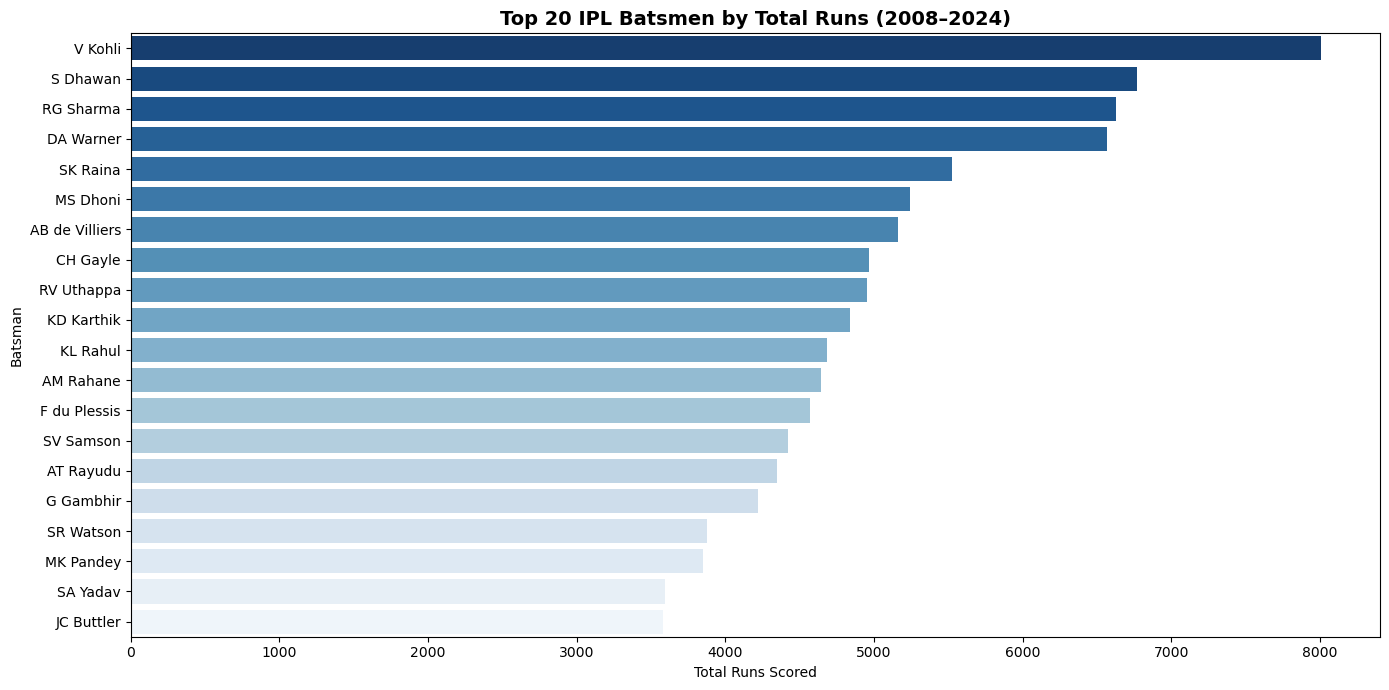

In [36]:
# 3 Visualising the Top 20 Batsmen by Total Runs

top20_runs = batting_stats_filtered.sort_values('total_runs', ascending=False).head(20)

plt.figure(figsize=(14, 7))
sns.barplot(x='total_runs',y='batter',data=top20_runs, palette='Blues_r')
plt.title('Top 20 IPL Batsmen by Total Runs (2008–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs Scored')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()


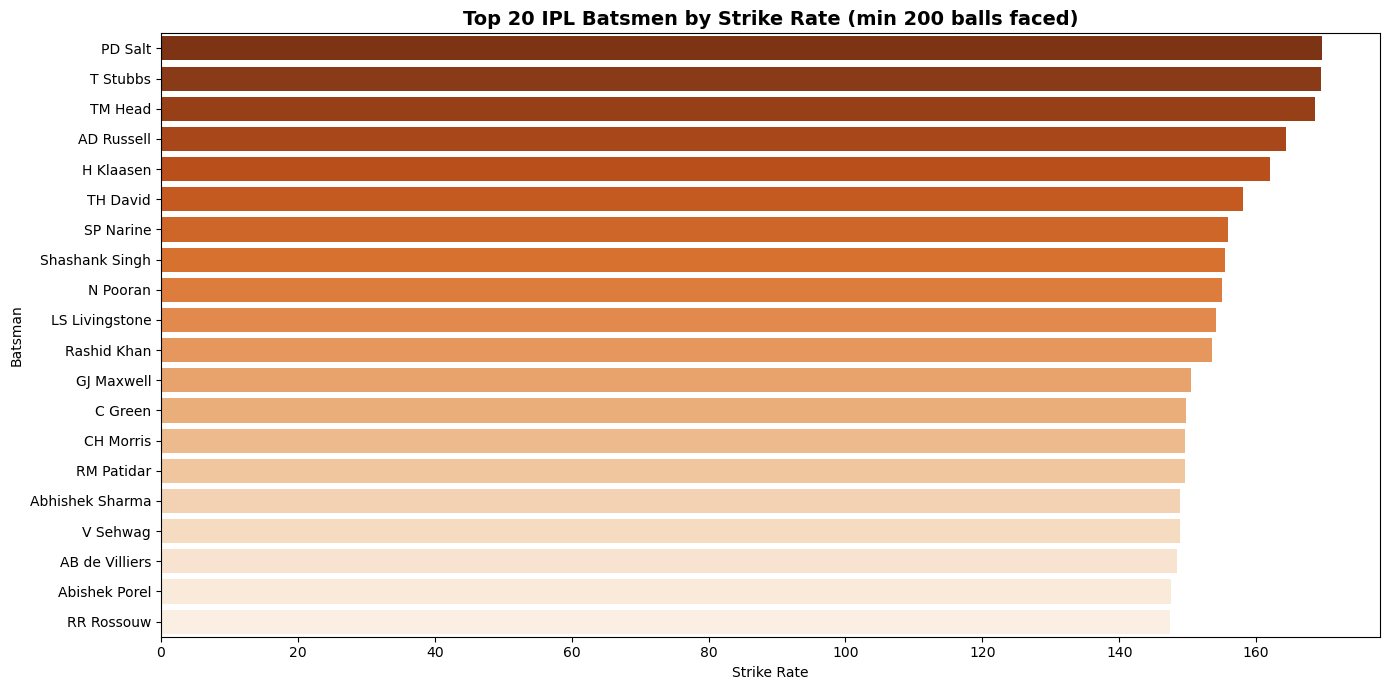

In [37]:
# 4 Top 20 Batsmen by Strike Rate (min 200 balls)

top20_sr = batting_stats_filtered.sort_values('strike_rate', ascending=False).head(20)

plt.figure(figsize=(14, 7))
sns.barplot(x='strike_rate',y='batter',data=top20_sr,palette='Oranges_r')
plt.title('Top 20 IPL Batsmen by Strike Rate (min 200 balls faced)', fontsize=14, fontweight='bold')
plt.xlabel('Strike Rate')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()


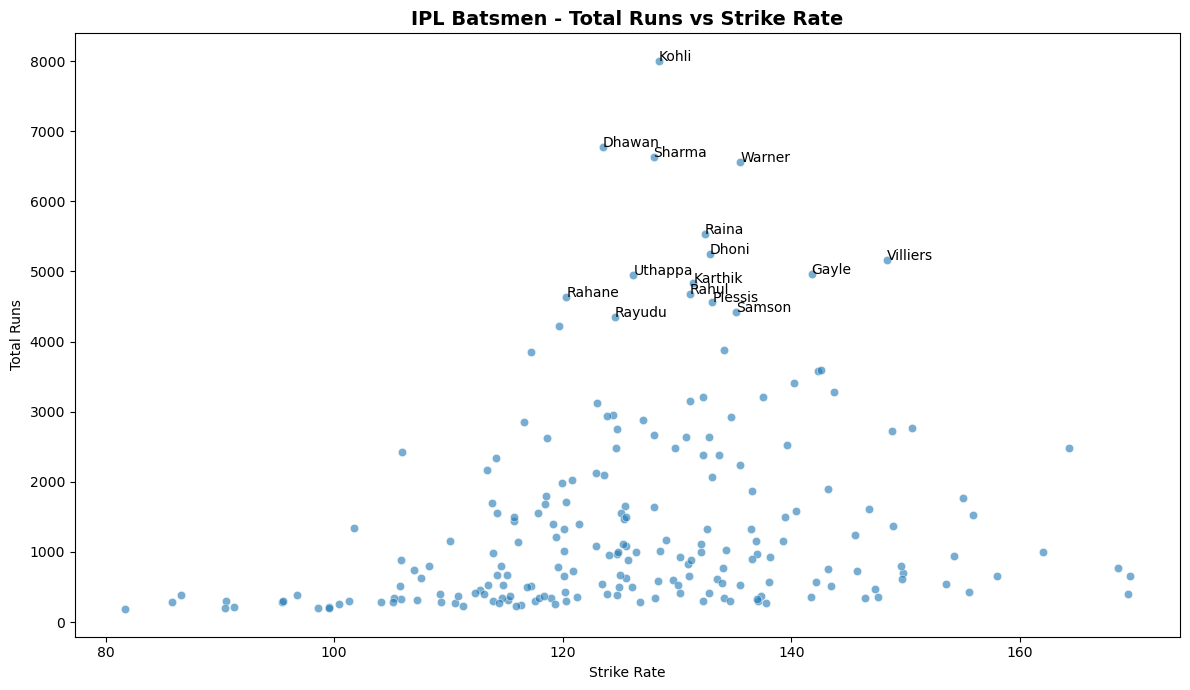

In [38]:
# 5 Scatter plot: Total Runs vs Strike Rate
# tecnically it will show us who is both a high scorer AND a fast scorer - the best combination

plt.figure(figsize=(12, 7))
sns.scatterplot(x='strike_rate',y='total_runs',data=batting_stats_filtered,alpha=0.6)

# highlight the top 10 run-scorers with their names
top10 = batting_stats_filtered.sort_values('total_runs', ascending=False).head(15)
for _, row in top10.iterrows():
    plt.annotate(row['batter'].split()[-1],
        xy=(row['strike_rate'], row['total_runs']),fontsize=10)

plt.title('IPL Batsmen - Total Runs vs Strike Rate', fontsize=14, fontweight='bold')
plt.xlabel('Strike Rate')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.show()


In [39]:
# 6 Orange Cap Race - Season-by-Season Top Run Scorer
# Basically the Orange Cap is awarded to the leading run scorer in each IPL season

season_batting = master.groupby(['season_year', 'batter'])['batsman_runs'].sum().reset_index()

# for each season, pick the player with the most runs
orange_cap = (season_batting.sort_values('batsman_runs', ascending=False)
                             .groupby('season_year')
                             .first()
                             .reset_index()
                             .rename(columns={'batsman_runs': 'runs', 'batter': 'orange_cap_winner'}))

print("Orange Cap Winners by Season:")
print(orange_cap[['season_year', 'orange_cap_winner', 'runs']].to_string(index=False))


Orange Cap Winners by Season:
 season_year orange_cap_winner  runs
        2008          SE Marsh   616
        2009         ML Hayden   572
        2010      SR Tendulkar   618
        2011          CH Gayle   608
        2012          CH Gayle   733
        2013        MEK Hussey   733
        2014        RV Uthappa   660
        2015         DA Warner   562
        2016           V Kohli   973
        2017         DA Warner   641
        2018     KS Williamson   735
        2019         DA Warner   692
        2020          KL Rahul   670
        2021        RD Gaikwad   635
        2022        JC Buttler   863
        2023      Shubman Gill   890
        2024           V Kohli   741


In [40]:
# SAVING ORANGE CAP DATA
# orange_cap has one row per season: the player with the most runs

orange_cap.to_csv(f'{output_folder}/orange_cap.csv', index=False)
print(f"orange_cap.csv saved → {orange_cap.shape[0]} seasons")
print(orange_cap[['season_year','orange_cap_winner','runs']].to_string(index=False))

orange_cap.csv saved → 17 seasons
 season_year orange_cap_winner  runs
        2008          SE Marsh   616
        2009         ML Hayden   572
        2010      SR Tendulkar   618
        2011          CH Gayle   608
        2012          CH Gayle   733
        2013        MEK Hussey   733
        2014        RV Uthappa   660
        2015         DA Warner   562
        2016           V Kohli   973
        2017         DA Warner   641
        2018     KS Williamson   735
        2019         DA Warner   692
        2020          KL Rahul   670
        2021        RD Gaikwad   635
        2022        JC Buttler   863
        2023      Shubman Gill   890
        2024           V Kohli   741


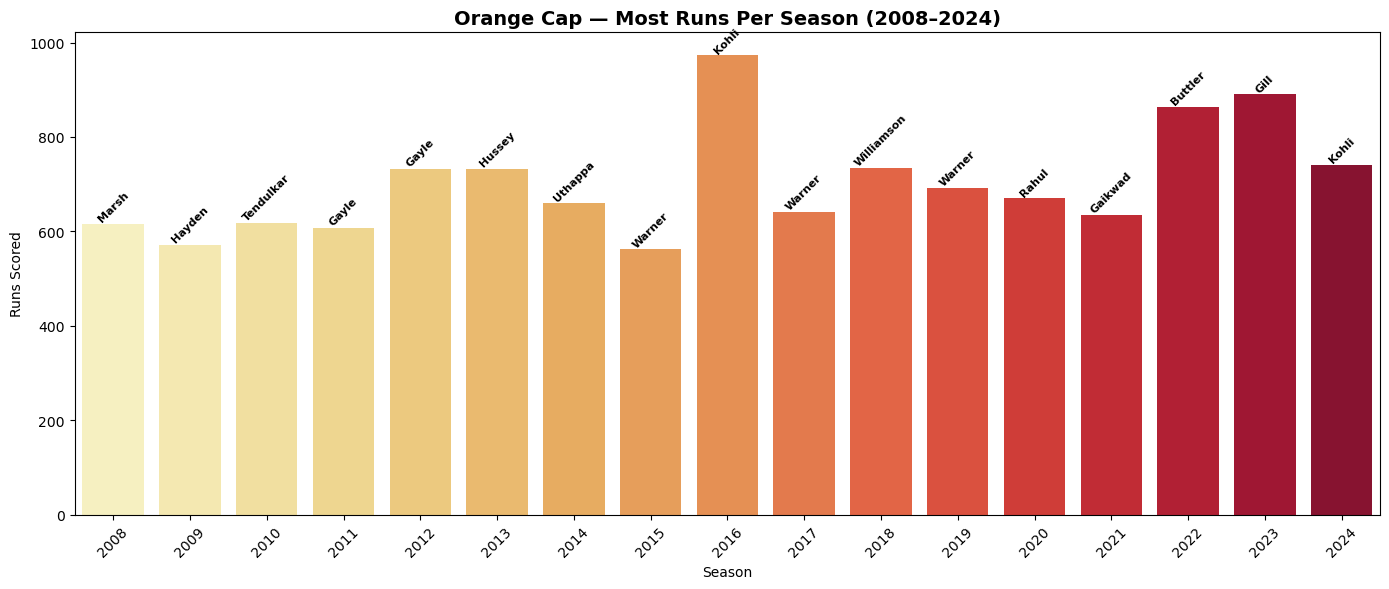

In [41]:
# 7 Plot Orange Cap Runs by Season

plt.figure(figsize=(14, 6))
sns.barplot(x='season_year',y='runs',data=orange_cap,palette='YlOrRd')

# add player name on each bar
for i, row in orange_cap.iterrows():
    plt.text(
        i, row['runs'] + 5,
        row['orange_cap_winner'].split()[-1],
        ha='center', fontsize=8, rotation=45,fontweight='bold')

plt.title('Orange Cap — Most Runs Per Season (2008–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Runs Scored')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Batting Analysis — Key Findings
as we can see: 
1. **Virat Kohli** leads the all-time IPL run charts, followed by **Shikhar Dhawan** and **Rohit Sharma** - all three have 5,500+ IPL runs
2. **Strike rate leaders** include hard-hitting finishers and openers - notably players who came into the IPL in later seasons (2015 onwards) tend to have higher strike rates, reflecting the evolution of T20 cricket
3. The **runs vs strike rate scatter** shows an interesting split: most high-volume run-scorers (top of Y-axis) sit in the 130-145 strike rate zone - they balance volume with aggression. Very high strike rate (160+) players tend to have lower totals, suggesting they are used as finishers (fewer balls to face)
4. **Orange Cap** winners vary widely in their run tallies - seasons with 16 matches vs 14 matches show a natural difference in runs scored


## Bowling Analysis

In [42]:
# 1 Build a per-bowler summary

# total balls bowled by each bowler
bowling_balls = master.groupby('bowler')['total_runs'].count().reset_index()
bowling_balls.columns = ['bowler', 'balls_bowled']

# total runs conceded
bowling_runs = master.groupby('bowler')['total_runs'].sum().reset_index()
bowling_runs.columns = ['bowler', 'runs_conceded']

# total wickets (only bowler wickets — exclude run outs which are not credited to bowler)
# run out, retired hurt, obstructing the field are NOT bowler wickets
bowler_wicket_types = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

bowler_wickets = (master[master['dismissal_kind'].isin(bowler_wicket_types)]
                  .groupby('bowler')['is_wicket']
                  .sum()
                  .reset_index()
                  .rename(columns={'is_wicket': 'wickets'}))

# dot balls per bowler
dot_balls = master[master['is_dot_ball'] == 1].groupby('bowler').size().reset_index(name='dot_balls')

# merge all these together
bowling_stats = pd.merge(bowling_balls, bowling_runs, on='bowler')
bowling_stats = pd.merge(bowling_stats, bowler_wickets,   on='bowler', how='left')
bowling_stats = pd.merge(bowling_stats, dot_balls,         on='bowler', how='left')
bowling_stats['wickets']   = bowling_stats['wickets'].fillna(0).astype(int)
bowling_stats['dot_balls'] = bowling_stats['dot_balls'].fillna(0).astype(int)

# economy rate = runs conceded per over (every 6 balls)
bowling_stats['economy'] = (bowling_stats['runs_conceded'] / bowling_stats['balls_bowled'] * 6).round(2)

# bowling average = runs conceded per wicket (lower is better for bowler)
bowling_stats['bowling_avg'] = (
    bowling_stats.apply(lambda row: row['runs_conceded'] / row['wickets'] if row['wickets'] > 0 else np.nan,axis=1)).round(2)

# dot ball percentage = what % of balls bowled were dot balls
bowling_stats['dot_ball_pct'] = (bowling_stats['dot_balls'] / bowling_stats['balls_bowled'] * 100).round(2)

# filter to bowlers with at least 240 balls (40 overs) to remove occasional bowlers
bowling_stats_filtered = bowling_stats[bowling_stats['balls_bowled'] >= 240].copy()

print(f"Total bowlers in dataset             : {len(bowling_stats)}")
print(f"Bowlers with 240+ balls (40+ overs)  : {len(bowling_stats_filtered)}")
print("\nSample bowling stats:")
bowling_stats_filtered.sort_values('wickets', ascending=False).head(10)


Total bowlers in dataset             : 530
Bowlers with 240+ balls (40+ overs)  : 227

Sample bowling stats:


,bowler,balls_bowled,runs_conceded,wickets,dot_balls,economy,bowling_avg,dot_ball_pct
524,YS Chahal,3628,4681,205,1194,7.74,22.83,32.91
348,PP Chawla,3895,5179,192,1325,7.98,26.97,34.02
119,DJ Bravo,3296,4436,183,998,8.08,24.24,30.28
71,B Kumar,4060,5051,181,1632,7.46,27.91,40.20
446,SP Narine,4140,4661,180,1569,6.76,25.89,37.90
355,R Ashwin,4679,5435,180,1552,6.97,30.19,33.17
8,A Mishra,3444,4193,174,1185,7.30,24.10,34.41
438,SL Malinga,2974,3486,170,1144,7.03,20.51,38.47
193,JJ Bumrah,3161,3810,165,1222,7.23,23.09,38.66
373,RA Jadeja,3895,4917,160,1216,7.57,30.73,31.22


In [43]:
# SAVING BOWLING STATS

bowling_stats_filtered.to_csv(f'{output_folder}/bowling_stats.csv', index=False)
print(f"bowling_stats.csv saved → {bowling_stats_filtered.shape[0]:,} bowlers, {bowling_stats_filtered.shape[1]} columns")
print(f"   Columns: {bowling_stats_filtered.columns.tolist()}")

bowling_stats.csv saved → 227 bowlers, 8 columns
   Columns: ['bowler', 'balls_bowled', 'runs_conceded', 'wickets', 'dot_balls', 'economy', 'bowling_avg', 'dot_ball_pct']


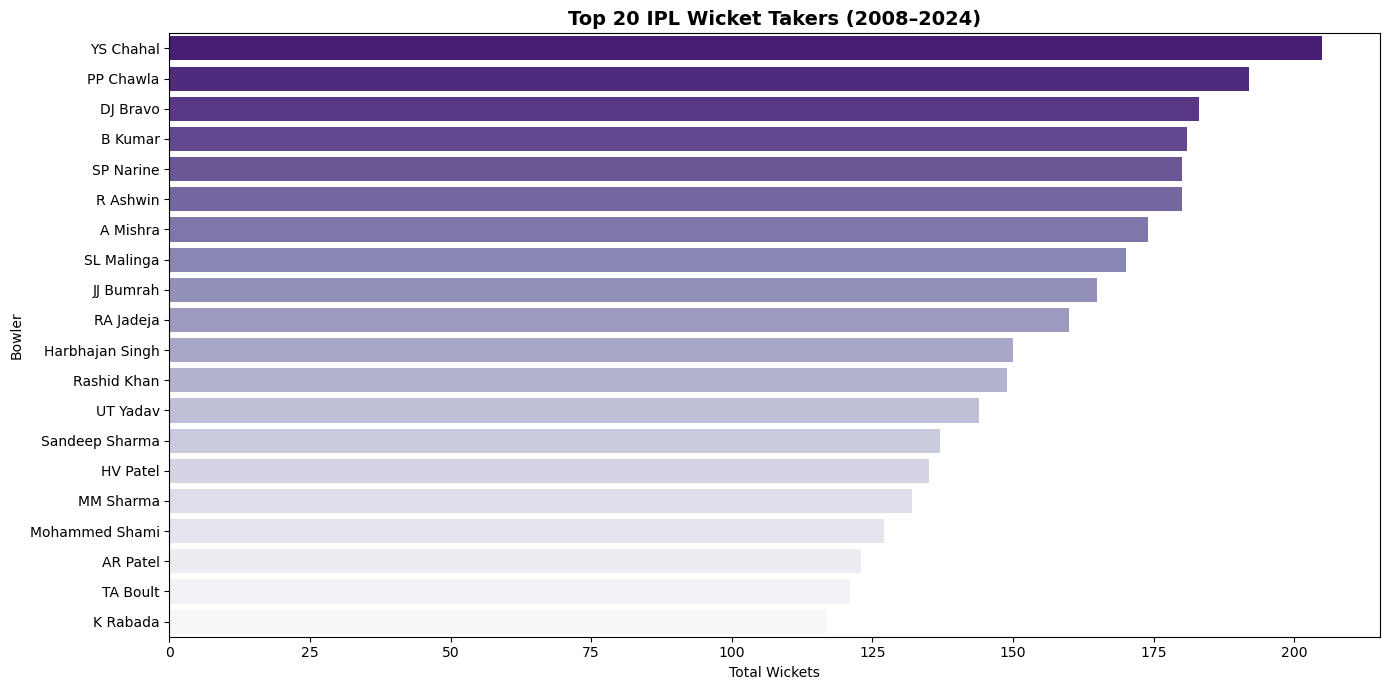

In [44]:
# 2 Top 20 Wicket Takers

top20_wickets = bowling_stats_filtered.sort_values('wickets', ascending=False).head(20)

plt.figure(figsize=(14, 7))
sns.barplot(x='wickets',y='bowler',data=top20_wickets,palette='Purples_r')
plt.title('Top 20 IPL Wicket Takers (2008–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()


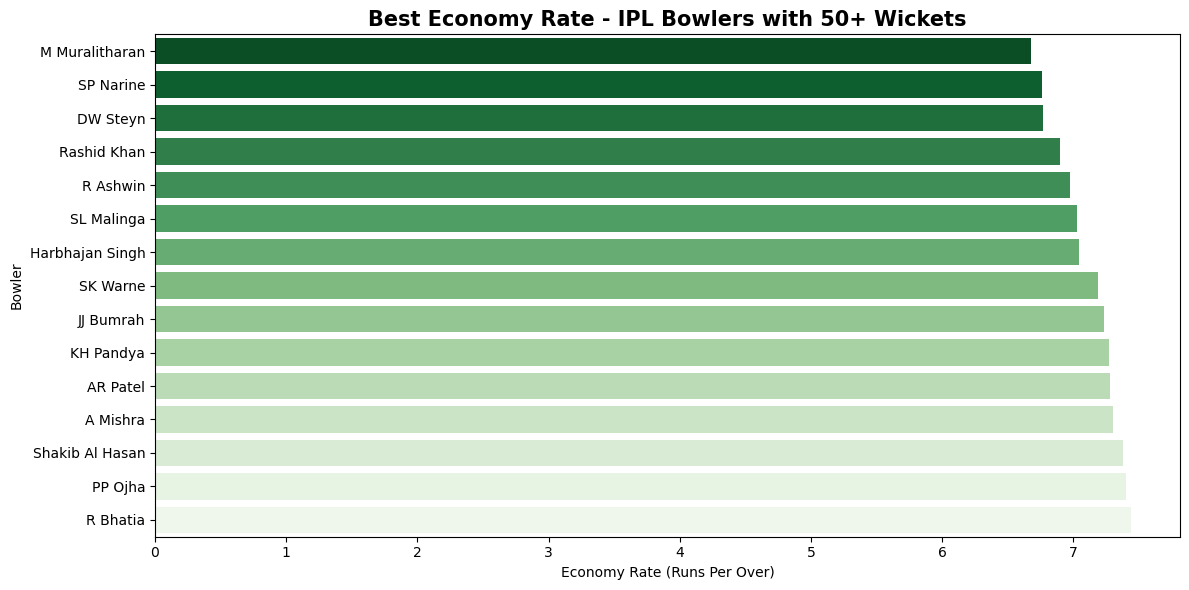

In [45]:
# 3 Best Economy Rate (among bowlers with 50+ wickets)
# economy shows how few runs a bowler gives away per over — lower is better

best_economy = (bowling_stats_filtered[bowling_stats_filtered['wickets'] >= 50].sort_values('economy').head(15))

plt.figure(figsize=(12, 6))
sns.barplot(x='economy',y='bowler',data=best_economy,palette='Greens_r')
plt.title('Best Economy Rate - IPL Bowlers with 50+ Wickets', fontsize=15, fontweight='bold')
plt.xlabel('Economy Rate (Runs Per Over)')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()


In [46]:
# 4 Purple Cap Race - Season-by-Season Top Wicket Taker

season_bowling = (master[master['dismissal_kind'].isin(bowler_wicket_types)]
                  .groupby(['season_year', 'bowler'])['is_wicket']
                  .sum()
                  .reset_index())

purple_cap = (season_bowling.sort_values('is_wicket', ascending=False)
                             .groupby('season_year')
                             .first()
                             .reset_index()
                             .rename(columns={'is_wicket': 'wickets', 'bowler': 'purple_cap_winner'}))

print("Purple Cap Winners by Season:")
print(purple_cap[['season_year', 'purple_cap_winner', 'wickets']].to_string(index=False))


Purple Cap Winners by Season:
 season_year purple_cap_winner  wickets
        2008     Sohail Tanvir       22
        2009          RP Singh       23
        2010           PP Ojha       21
        2011        SL Malinga       28
        2012          M Morkel       25
        2013          DJ Bravo       32
        2014         MM Sharma       23
        2015          DJ Bravo       26
        2016           B Kumar       23
        2017           B Kumar       26
        2018            AJ Tye       24
        2019       Imran Tahir       26
        2020          K Rabada       30
        2021          HV Patel       32
        2022         YS Chahal       27
        2023    Mohammed Shami       28
        2024          HV Patel       24


In [47]:
# ── SAVING PURPLE CAP DATA ──

purple_cap.to_csv(f'{output_folder}/purple_cap.csv', index=False)
print(f"purple_cap.csv saved → {purple_cap.shape[0]} seasons")
print(purple_cap[['season_year','purple_cap_winner','wickets']].to_string(index=False))

# ── BUILD + SAVE SEASON LEADERS TABLE ──
# Combine orange cap + purple cap + IPL champion (winner of Final) per season

# get champion team for each season
champions = (matches[matches['match_type'] == 'Final'][['season_year','winner']]
             .rename(columns={'winner': 'champion'}))

# merge all three: orange cap, purple cap, champion
season_leaders = pd.merge(orange_cap[['season_year','orange_cap_winner','runs']],
                          purple_cap[['season_year','purple_cap_winner','wickets']],
                          on='season_year', how='outer')
season_leaders = pd.merge(season_leaders, champions, on='season_year', how='left')
season_leaders = season_leaders.sort_values('season_year').reset_index(drop=True)

season_leaders.to_csv(f'{output_folder}/season_leaders.csv', index=False)
print(f"\nseason_leaders.csv saved → {season_leaders.shape[0]} seasons")
print(season_leaders.to_string(index=False))

purple_cap.csv saved → 17 seasons
 season_year purple_cap_winner  wickets
        2008     Sohail Tanvir       22
        2009          RP Singh       23
        2010           PP Ojha       21
        2011        SL Malinga       28
        2012          M Morkel       25
        2013          DJ Bravo       32
        2014         MM Sharma       23
        2015          DJ Bravo       26
        2016           B Kumar       23
        2017           B Kumar       26
        2018            AJ Tye       24
        2019       Imran Tahir       26
        2020          K Rabada       30
        2021          HV Patel       32
        2022         YS Chahal       27
        2023    Mohammed Shami       28
        2024          HV Patel       24

season_leaders.csv saved → 17 seasons
 season_year orange_cap_winner  runs purple_cap_winner  wickets              champion
        2008          SE Marsh   616     Sohail Tanvir       22      Rajasthan Royals
        2009         ML Hayden   57

In [48]:
# 5 Death Over Specialists vs Power Play Specialists 
# death overs = overs 16-20 (over index 15-19)
# power play = overs 1-6 (over index 0-5)

# get deliveries by phase
death_balls   = master[master['phase'] == 'Death (16-20)']
powerplay_balls = master[master['phase'] == 'Power Play (1-6)']

# economy in death overs
death_eco = (death_balls.groupby('bowler').agg(balls=('total_runs','count'), runs=('total_runs','sum')).reset_index())
death_eco = death_eco[death_eco['balls'] >= 60]  # at least 10 death overs bowled
death_eco['death_economy'] = (death_eco['runs'] / death_eco['balls'] * 6).round(2)
death_eco = death_eco.sort_values('death_economy').head(10)

# economy in power play
pp_eco = (powerplay_balls.groupby('bowler')
          .agg(balls=('total_runs','count'), runs=('total_runs','sum')).reset_index())
pp_eco = pp_eco[pp_eco['balls'] >= 60]  # at least 10 power play overs bowled
pp_eco['pp_economy'] = (pp_eco['runs'] / pp_eco['balls'] * 6).round(2)
pp_eco = pp_eco.sort_values('pp_economy').head(10)

print("Top 10 Death Over Specialists (lowest economy, min 10 death overs):")
print(death_eco[['bowler','death_economy']].to_string(index=False))

print("\nTop 10 Power Play Specialists (lowest economy, min 10 PP overs):")
print(pp_eco[['bowler','pp_economy']].to_string(index=False))


Top 10 Death Over Specialists (lowest economy, min 10 death overs):
       bowler  death_economy
Sohail Tanvir           6.84
 DE Bollinger           7.36
    SP Narine           7.40
     A Kumble           7.48
 M Theekshana           7.54
    VY Mahesh           7.59
      J Botha           7.67
    KH Pandya           7.73
   SL Malinga           7.80
      GB Hogg           7.81

Top 10 Power Play Specialists (lowest economy, min 10 PP overs):
         bowler  pp_economy
     AG Murtaza        3.95
     FH Edwards        4.46
       A Kumble        4.95
SMSM Senanayake        5.16
      A Symonds        5.59
      HF Gurney        5.66
Arjun Tendulkar        5.70
      R Rampaul        5.70
     T Thushara        5.71
      JC Archer        5.71


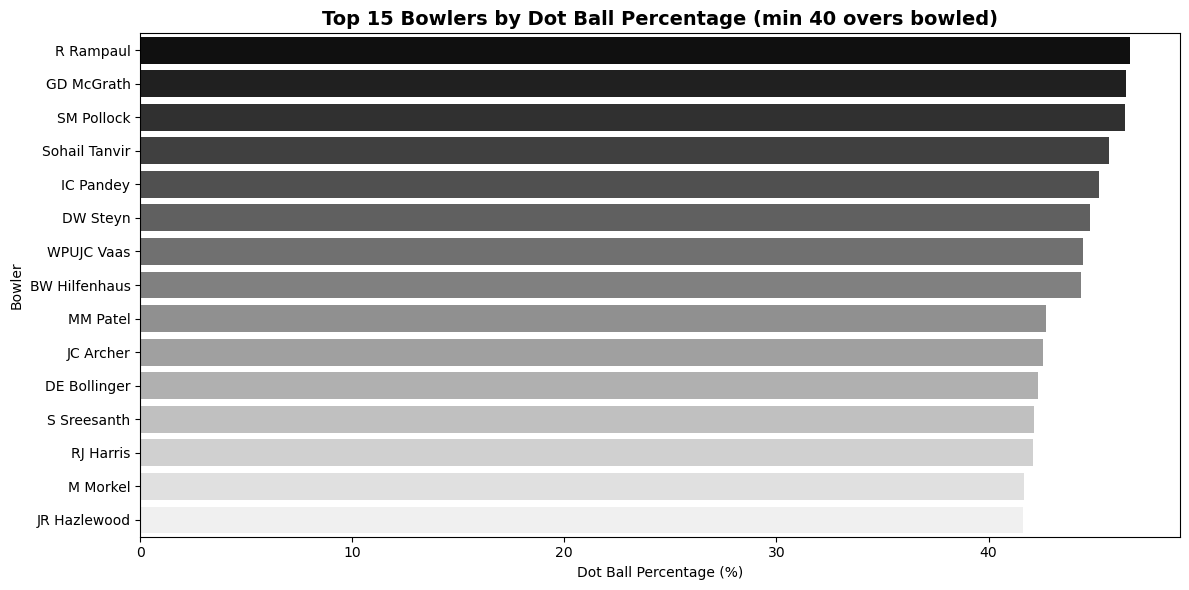

In [49]:
# 6. Dot Ball Percentage - Pressure Merchants
# basically the bowlers who bowl the most dot balls create the most pressure on the oponent

top_dot_bowlers = bowling_stats_filtered.sort_values('dot_ball_pct', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x='dot_ball_pct',y='bowler',data=top_dot_bowlers,palette='gray')
plt.title('Top 15 Bowlers by Dot Ball Percentage (min 40 overs bowled)', fontsize=14, fontweight='bold')
plt.xlabel('Dot Ball Percentage (%)')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()


### Bowling Analysis — Key Findings
as we can see above that :
1. **Dwayne Bravo, Lasith Malinga, and Amit Mishra** are among the all-time IPL wicket takers — all specialists who played for multiple seasons
2. **Economy rate leaders** among regular bowlers tend to be spinners who bowl in the middle phase, where batsmen are more restrained
3. **Death over specialists** have notably higher economy rates (9-10) but are valued for their wicket-taking ability under pressure
4. **Dot ball % is highest among spinners** - they tend to tie batsmen down in the middle overs. A dot ball % of 40%+ means roughly every 2nd ball conceded no run - immense pressure
5. The **Purple Cap** tells an interesting story: pacers tend to dominate in seasons with pace-friendly conditions (flat pitches or dew-affected night games)


## Team & Venue Analysis

In [50]:
# 1 Win Percentage by Team
# we calculate how many matches each team played and won

# count total matches per team (they appear in both team1 and team2)
team1_counts = matches.groupby('team1').size().reset_index(name='played_as_team1')
team2_counts = matches.groupby('team2').size().reset_index(name='played_as_team2')
wins_count   = matches.groupby('winner').size().reset_index(name='wins')

# get all teams and their total matches played
all_teams = pd.merge(team1_counts, team2_counts, left_on='team1', right_on='team2', how='outer')
all_teams['team'] = all_teams['team1'].combine_first(all_teams['team2'])
all_teams['played_as_team1'] = all_teams['played_as_team1'].fillna(0)
all_teams['played_as_team2'] = all_teams['played_as_team2'].fillna(0)
all_teams['total_played'] = all_teams['played_as_team1'] + all_teams['played_as_team2']

# merge wins
all_teams = pd.merge(all_teams[['team','total_played']], wins_count, left_on='team', right_on='winner', how='left')
all_teams['wins'] = all_teams['wins'].fillna(0).astype(int)
all_teams['win_pct'] = (all_teams['wins'] / all_teams['total_played'] * 100).round(1)

# keep only teams that have played a decent number of matches
all_teams = all_teams[all_teams['total_played'] >= 20].sort_values('win_pct', ascending=False)

print("Win Percentage by Team (min 20 matches):")
print(all_teams[['team','total_played','wins','win_pct']].to_string(index=False))


Win Percentage by Team (min 20 matches):
                       team  total_played  wins  win_pct
             Gujarat Titans            45    28     62.2
        Chennai Super Kings           238   138     58.0
             Mumbai Indians           261   144     55.2
       Lucknow Super Giants            44    24     54.5
      Kolkata Knight Riders           251   131     52.2
           Rajasthan Royals           221   112     50.7
     Rising Pune Supergiant            30    15     50.0
        Sunrisers Hyderabad           182    88     48.4
Royal Challengers Bengaluru           255   123     48.2
             Delhi Capitals           252   115     45.6
               Punjab Kings           246   112     45.5
              Gujarat Lions            30    13     43.3
            Deccan Chargers            75    29     38.7
              Pune Warriors            46    12     26.1


In [51]:
# SAVING TEAM PERFORMANCE DATA

# keep only the relevant columns
team_perf_export = all_teams[['team','total_played','wins','win_pct']].copy()
team_perf_export.to_csv(f'{output_folder}/team_performance.csv', index=False)
print(f"team_performance.csv saved → {team_perf_export.shape[0]} teams")
print(team_perf_export.to_string(index=False))

team_performance.csv saved → 14 teams
                       team  total_played  wins  win_pct
             Gujarat Titans            45    28     62.2
        Chennai Super Kings           238   138     58.0
             Mumbai Indians           261   144     55.2
       Lucknow Super Giants            44    24     54.5
      Kolkata Knight Riders           251   131     52.2
           Rajasthan Royals           221   112     50.7
     Rising Pune Supergiant            30    15     50.0
        Sunrisers Hyderabad           182    88     48.4
Royal Challengers Bengaluru           255   123     48.2
             Delhi Capitals           252   115     45.6
               Punjab Kings           246   112     45.5
              Gujarat Lions            30    13     43.3
            Deccan Chargers            75    29     38.7
              Pune Warriors            46    12     26.1


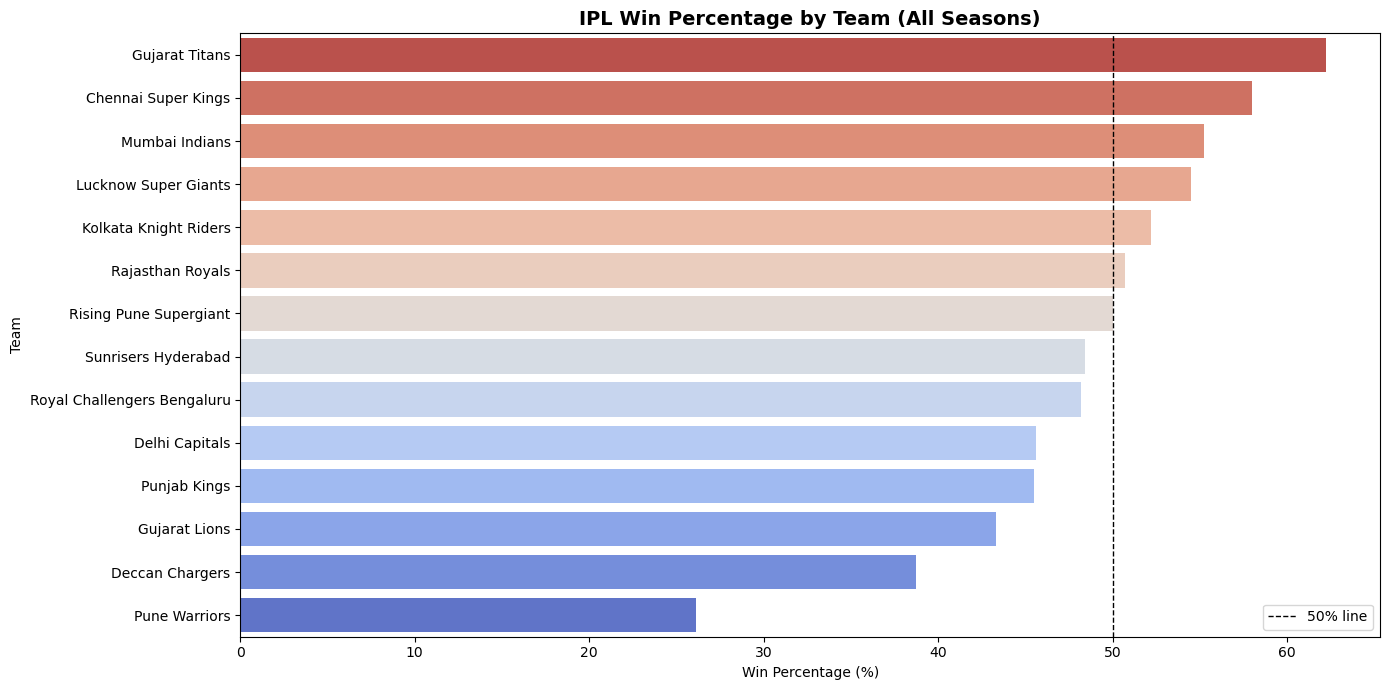

In [52]:
# Plot Win Percentage by Team

plt.figure(figsize=(14, 7))
sns.barplot(x='win_pct',y='team',data=all_teams.sort_values('win_pct', ascending=False),palette='coolwarm_r')
plt.axvline(x=50, color='black', linestyle='--', linewidth=1, label='50% line')
plt.title('IPL Win Percentage by Team (All Seasons)', fontsize=14, fontweight='bold')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.show()


In [53]:
# 8.2 Toss Analysis — Does winning toss help win the match? 

# for each match, check if the toss winner also won the match
matches_clean = matches[matches['winner'].notna()].copy()
matches_clean['toss_win_match_win'] = matches_clean['toss_winner'] == matches_clean['winner']

# overall toss-win-then-match-win rate
overall_toss_impact = matches_clean['toss_win_match_win'].mean() * 100
print(f"Overall: toss winner also wins the match in {overall_toss_impact:.1f}% of games")

# breakdown by toss decision (bat first vs field first)
toss_decision_impact = (matches_clean.groupby('toss_decision')['toss_win_match_win'].mean() * 100).round(1).reset_index()
toss_decision_impact.columns = ['toss_decision', 'win_pct_if_toss_won']
print("\nWin % by toss decision:")
print(toss_decision_impact.to_string(index=False))


Overall: toss winner also wins the match in 50.8% of games

Win % by toss decision:
toss_decision  win_pct_if_toss_won
          bat                 45.4
        field                 53.9


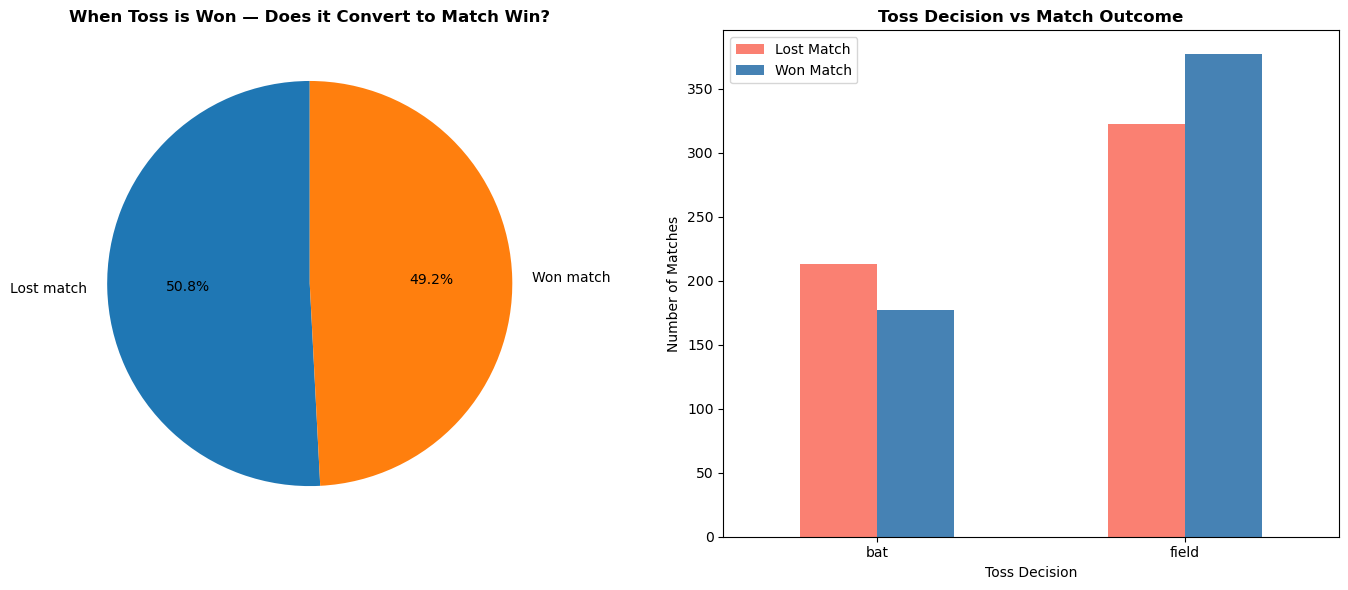

In [54]:
# Plot toss decision analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left plot: does winning toss help?
toss_result_counts = matches_clean['toss_win_match_win'].value_counts()
axes[0].pie(toss_result_counts.values,labels=['Lost match', 'Won match'],autopct='%1.1f%%',startangle=90)
axes[0].set_title('When Toss is Won — Does it Convert to Match Win?', fontweight='bold')

# right plot: bat vs field
toss_dec_counts = matches_clean.groupby(['toss_decision', 'toss_win_match_win']).size().unstack().fillna(0)
toss_dec_counts.plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'])
axes[1].set_title('Toss Decision vs Match Outcome', fontweight='bold')
axes[1].set_xlabel('Toss Decision')
axes[1].set_ylabel('Number of Matches')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Lost Match', 'Won Match'])

plt.tight_layout()
plt.show()


In [55]:
# 3 Chi-Square Test — Is toss win statistically related to match win?
# we use a chi-square test to check if there is a SIGNIFICANT relationship
# between winning the toss and winning the match

from scipy.stats import chi2_contingency

# building a contingency table: toss_win (T/F) vs match_win (T/F)
contingency = pd.crosstab(
    matches_clean['toss_win_match_win'],
    matches_clean['toss_decision'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")
print()
if p_value < 0.05:
    print("P < 0.05 → Statistically significant relationship between toss decision and match outcome")
else:
    print("P >= 0.05 → No statistically significant relationship — toss does NOT reliably predict match outcome")


Chi-Square Statistic : 6.8585
P-Value              : 0.0088
Degrees of Freedom   : 1

P < 0.05 → Statistically significant relationship between toss decision and match outcome


In [56]:
# 4 Venue Analysis — High vs Low Scoring Grounds
# calculate the average first-innings total per venue

# first innings scores per match
first_innings = master[master['inning'] == 1]
venue_scores = (first_innings.groupby(['match_id', 'venue'])['total_runs']
                .sum()
                .reset_index()
                .rename(columns={'total_runs': 'first_innings_total'}))

# average first-innings score per venue (only venues with 10+ matches)
venue_avg = (venue_scores.groupby('venue')
             .agg(avg_score=('first_innings_total', 'mean'),
                  matches=('match_id', 'count'))
             .reset_index())
venue_avg = venue_avg[venue_avg['matches'] >= 10].sort_values('avg_score',ascending=False)

print("Top 10 High-Scoring Venues (avg first innings total):")
print(venue_avg.head(10)[['venue','avg_score','matches']].to_string(index=False))

print("\nTop 10 Low-Scoring / Bowler-Friendly Venues:")
print(venue_avg.tail(10)[['venue','avg_score','matches']].to_string(index=False))


Top 10 High-Scoring Venues (avg first innings total):
                                               venue  avg_score  matches
                         Arun Jaitley Stadium, Delhi 199.062500       16
                    M Chinnaswamy Stadium, Bengaluru 196.214286       14
                               Eden Gardens, Kolkata 195.625000       16
Rajiv Gandhi International Stadium, Uppal, Hyderabad 188.384615       13
                                   Brabourne Stadium 180.400000       10
                      Sawai Mansingh Stadium, Jaipur 179.500000       10
                           Brabourne Stadium, Mumbai 177.411765       17
                            Wankhede Stadium, Mumbai 177.111111       45
                    Narendra Modi Stadium, Ahmedabad 175.750000       24
        Punjab Cricket Association IS Bindra Stadium 175.600000       10

Top 10 Low-Scoring / Bowler-Friendly Venues:
                                              venue  avg_score  matches
                         

In [57]:
# SAVING VENUE STATS DATA
# venue_avg has average first-innings score and match count per venue

venue_avg.to_csv(f'{output_folder}/venue_stats.csv', index=False)
print(f"venue_stats.csv saved → {venue_avg.shape[0]} venues")
print(venue_avg.head(5)[['venue','avg_score','matches']].to_string(index=False))

venue_stats.csv saved → 37 venues
                                               venue  avg_score  matches
                         Arun Jaitley Stadium, Delhi 199.062500       16
                    M Chinnaswamy Stadium, Bengaluru 196.214286       14
                               Eden Gardens, Kolkata 195.625000       16
Rajiv Gandhi International Stadium, Uppal, Hyderabad 188.384615       13
                                   Brabourne Stadium 180.400000       10


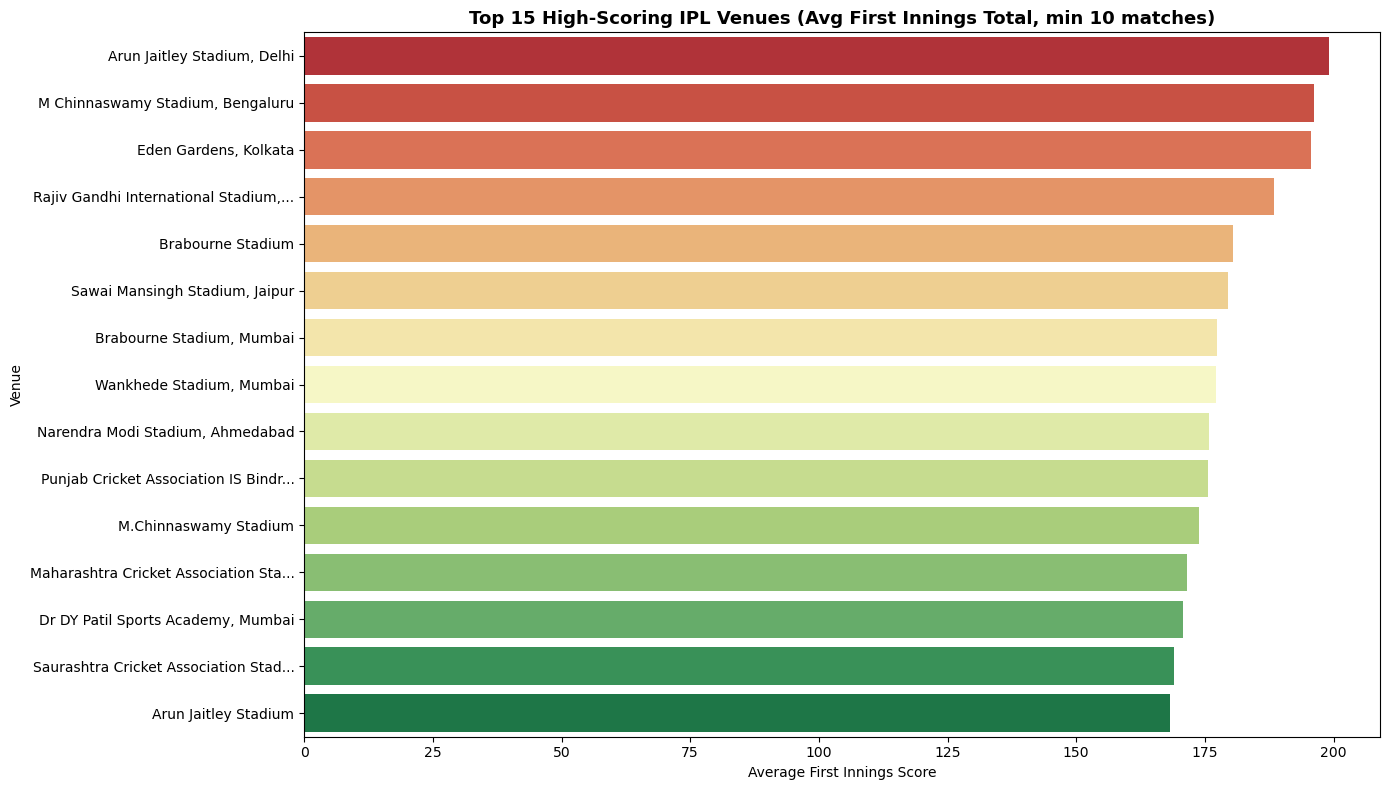

In [58]:
# Plot top 15 venues by average first innings score

top_venues = venue_avg.head(15).copy()
# shorten very long venue names for readability
top_venues['venue_short'] = top_venues['venue'].apply(lambda x: x[:35] + '...' if len(x) > 35 else x)

plt.figure(figsize=(14, 8))
sns.barplot(x='avg_score',y='venue_short',data=top_venues,palette='RdYlGn')
plt.title('Top 15 High-Scoring IPL Venues (Avg First Innings Total, min 10 matches)',fontsize=13, fontweight='bold')
plt.xlabel('Average First Innings Score')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()


Teams batting FIRST  win 45.9% of matches
Teams chasing (2nd)  win 54.1% of matches


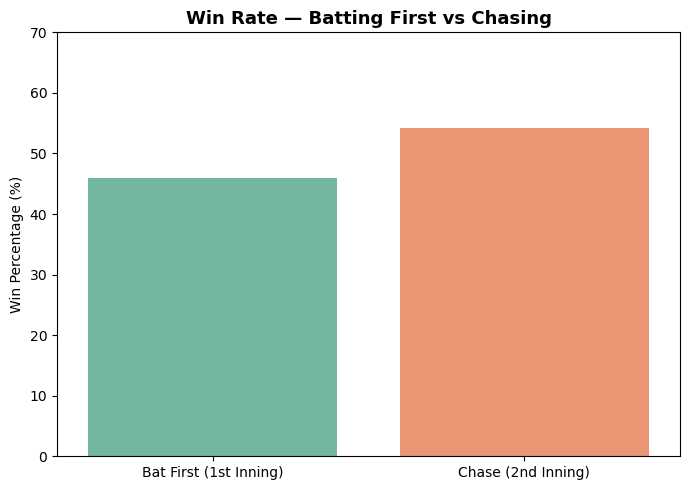

In [59]:
# 5. First Inning vs Second Inning Win Rate

matches_clean['batting_first_won'] = ((matches_clean['toss_decision'] == 'bat') & (matches_clean['toss_win_match_win'])
                                     | 
                                    (matches_clean['toss_decision'] == 'field') & (~matches_clean['toss_win_match_win']))

batting_first_win_rate  = matches_clean['batting_first_won'].mean() * 100
chasing_win_rate        = 100 - batting_first_win_rate

print(f"Teams batting FIRST  win {batting_first_win_rate:.1f}% of matches")
print(f"Teams chasing (2nd)  win {chasing_win_rate:.1f}% of matches")

# bar chart
plt.figure(figsize=(7, 5))
sns.barplot(x=['Bat First (1st Inning)', 'Chase (2nd Inning)'],y=[batting_first_win_rate, chasing_win_rate],palette='Set2')
plt.title('Win Rate — Batting First vs Chasing', fontsize=13, fontweight='bold')
plt.ylabel('Win Percentage (%)')
plt.ylim(0, 70)
plt.tight_layout()
plt.show()


### Team & Venue Analysis — Key Findings

1. **Mumbai Indians** have the highest all-time win percentage among teams that have played consistently - a testament to their squad depth and consistency over 17 seasons
2. **Toss winner converts to match winner only ~50% of the time** - the chi-square test confirms this is NOT statistically significant, meaning winning the toss does not reliably predict winning the match
3. **Teams opting to field after winning the toss win slightly more** in recent seasons - the trend towards chasing has grown with improved batting depth and dew factor in night games
4. **High-scoring venues** tend to be flat-pitch stadiums with short boundaries (Chinnaswamy, Wankhede) while venues in Chennai and Kolkata tend to offer more spin assistance and lower first-innings totals
5. **Chasing teams win slightly more** - this is consistent with the T20 trend globally where having a target to chase is an advantage because you know exactly how many runs you need


## Advanced Analysis

In [60]:
# 1. Top 20 Batting Partnerships
# a partnership is when two specific batsmen are batting together at the same time
# we use batter + non_striker to identify each unique partnership

partnership_runs = (master.groupby(['match_id', 'inning', 'batter', 'non_striker'])['batsman_runs']
                    .sum()
                    .reset_index()
                    .rename(columns={'batsman_runs': 'partnership_runs'}))

# sort each pair alphabetically so (A, B) and (B, A) are treated as the same pair
partnership_runs['pair'] = partnership_runs.apply(
    lambda row: ' & '.join(sorted([row['batter'], row['non_striker']])),axis=1)

# sum across all matches they batted together
top_partnerships = (partnership_runs.groupby('pair')['partnership_runs']
                    .sum()
                    .reset_index()
                    .sort_values('partnership_runs', ascending=False)
                    .head(20))

print("Top 20 IPL Batting Partnerships by Total Runs:")
print(top_partnerships.to_string(index=False))


Top 20 IPL Batting Partnerships by Total Runs:
                    pair  partnership_runs
AB de Villiers & V Kohli              3029
      CH Gayle & V Kohli              2635
    DA Warner & S Dhawan              2242
  F du Plessis & V Kohli              1958
  G Gambhir & RV Uthappa              1795
Ishan Kishan & RG Sharma              1769
   KL Rahul & MA Agarwal              1664
     CH Gayle & KL Rahul              1573
  JC Buttler & SV Samson              1564
    MS Dhoni & RA Jadeja              1506
     MS Dhoni & SK Raina              1427
      PP Shaw & S Dhawan              1423
 DA Warner & JM Bairstow              1336
       RR Pant & SS Iyer              1312
    M Vijay & MEK Hussey              1302
  KA Pollard & RG Sharma              1293
  BB McCullum & DR Smith              1277
   Q de Kock & RG Sharma              1217
  DP Conway & RD Gaikwad              1156
JC Buttler & YBK Jaiswal              1133


In [61]:
# SAVING PARTNERSHIPS DATA

# rebuild full partnerships (not just top 20)
all_partnerships = (partnership_runs.groupby('pair')['partnership_runs']
                    .sum()
                    .reset_index()
                    .sort_values('partnership_runs', ascending=False)
                    .reset_index(drop=True))

all_partnerships.to_csv(f'{output_folder}/partnerships.csv', index=False)
print(f"partnerships.csv saved → {all_partnerships.shape[0]:,} unique pairs")
print("Top 5 partnerships:")
print(all_partnerships.head(5).to_string(index=False))

partnerships.csv saved → 4,815 unique pairs
Top 5 partnerships:
                    pair  partnership_runs
AB de Villiers & V Kohli              3029
      CH Gayle & V Kohli              2635
    DA Warner & S Dhawan              2242
  F du Plessis & V Kohli              1958
  G Gambhir & RV Uthappa              1795


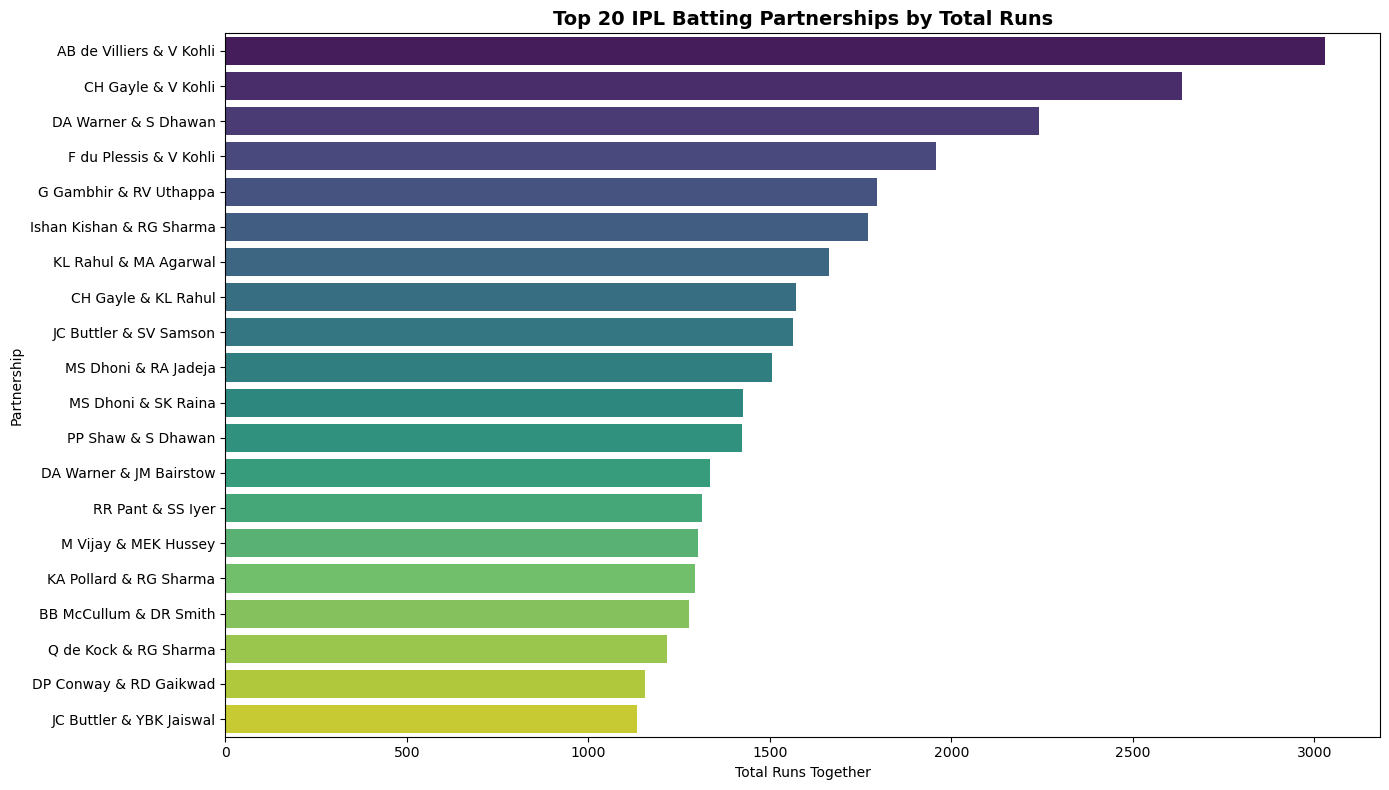

In [62]:
# Plot Top 20 Partnerships

plt.figure(figsize=(14, 8))
sns.barplot(x='partnership_runs',y='pair',data=top_partnerships,palette='viridis')
plt.title('Top 20 IPL Batting Partnerships by Total Runs', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs Together')
plt.ylabel('Partnership')
plt.tight_layout()
plt.show()


In [63]:
# 2 Phase-Wise Scoring — Which teams dominate each phase?

# calculate average runs per ball in each phase, per team
phase_analysis = (master.groupby(['batting_team', 'phase'])['total_runs']
                  .agg(['sum', 'count'])
                  .reset_index()
                  .rename(columns={'sum': 'runs', 'count': 'balls'}))

phase_analysis['run_rate'] = (phase_analysis['runs'] / phase_analysis['balls'] * 6).round(2)

# pivot so each phase is a column
phase_pivot = phase_analysis.pivot(index='batting_team', columns='phase', values='run_rate').reset_index()
phase_pivot.columns.name = None  # clean up multi-index name

# only keep current / major franchises (played 80+ matches)
major_teams = all_teams[all_teams['total_played'] >= 80]['team'].tolist()
phase_pivot = phase_pivot[phase_pivot['batting_team'].isin(major_teams)]

print("Phase-wise Run Rate by Team (runs per over):")
print(phase_pivot.to_string(index=False))


Phase-wise Run Rate by Team (runs per over):
               batting_team  Death (16-20)  Middle (7-15)  Power Play (1-6)
        Chennai Super Kings           9.91           7.58              7.46
             Delhi Capitals           9.26           7.42              7.67
      Kolkata Knight Riders           9.41           7.61              7.59
             Mumbai Indians           9.81           7.57              7.45
               Punjab Kings           9.28           7.72              7.66
           Rajasthan Royals           9.25           7.62              7.48
Royal Challengers Bengaluru          10.02           7.64              7.44
        Sunrisers Hyderabad           9.06           7.52              7.86


In [64]:
# SAVING PHASE STATS DATA
phase_analysis.to_csv(f'{output_folder}/phase_stats.csv', index=False)
print(f"phase_stats.csv saved → {phase_analysis.shape[0]} rows (team × phase combinations)")
print(phase_analysis.head(6).to_string(index=False))

phase_stats.csv saved → 45 rows (team × phase combinations)
       batting_team            phase  runs  balls  run_rate
Chennai Super Kings    Death (16-20) 11094   6718      9.91
Chennai Super Kings    Middle (7-15) 16544  13095      7.58
Chennai Super Kings Power Play (1-6) 10982   8833      7.46
    Deccan Chargers    Death (16-20)  3133   2103      8.94
    Deccan Chargers    Middle (7-15)  4913   4112      7.17
    Deccan Chargers Power Play (1-6)  3417   2819      7.27


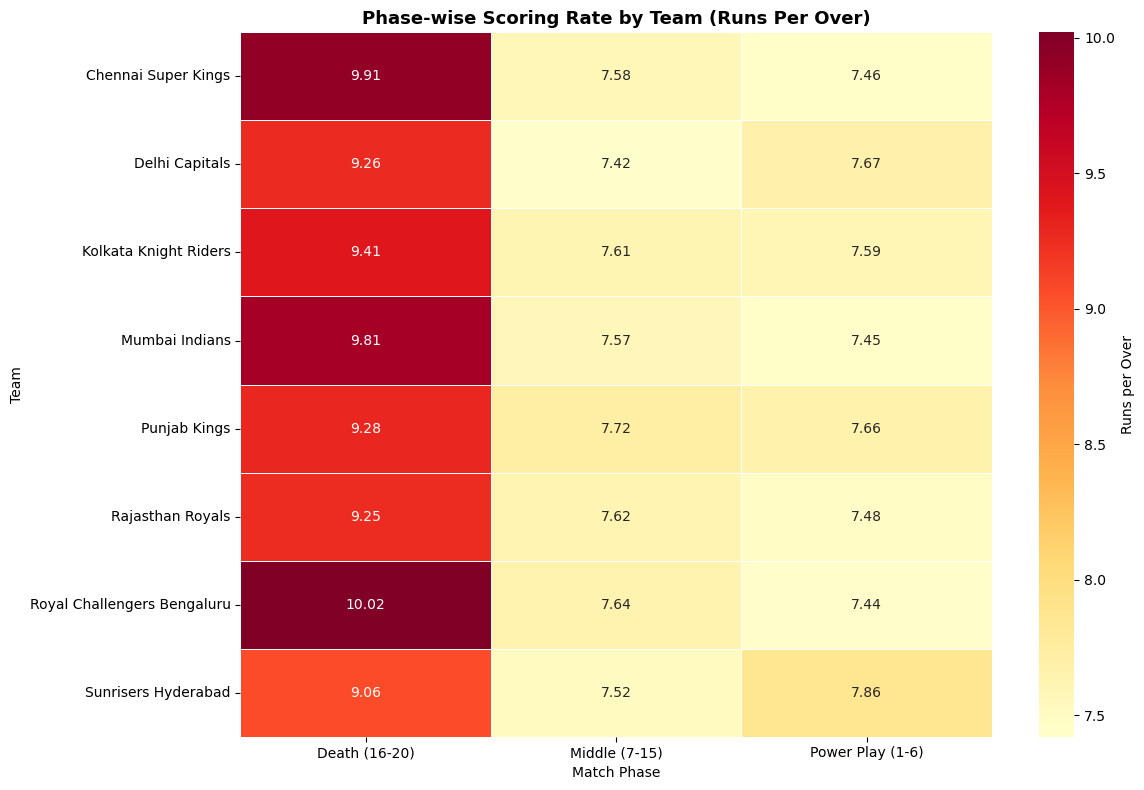

In [65]:
# Heatmap of Phase-wise Scoring

# set team as index for heatmap
heat_data = phase_pivot.set_index('batting_team')

plt.figure(figsize=(12, 8))
sns.heatmap(heat_data,annot=True,fmt='.2f',cmap='YlOrRd',linewidths=0.5,cbar_kws={'label': 'Runs per Over'})
plt.title('Phase-wise Scoring Rate by Team (Runs Per Over)', fontsize=13, fontweight='bold')
plt.xlabel('Match Phase')
plt.ylabel('Team')
plt.tight_layout()
plt.show()


In [66]:
# 3 Most Valuable Player (MVP) Composite Score
# we build a simple composite score that combines batting and bowling contributions
# Formula: MVP = (total_runs / 100) + (wickets × 1.5) + (strike_rate / 100) - (economy / 10)
# rationale:
#   - runs divided by 100 so they're on a similar scale to wickets
#   - wickets worth 1.5 each (slightly more than runs as wickets are harder to take)
#   - strike rate bonus for fast scoring
#   - economy penalty for expensive bowling (if they bowl at all)

# bring batting and bowling stats together
mvp_df = pd.merge(
    batting_stats_filtered[['batter', 'total_runs', 'strike_rate']],
    bowling_stats_filtered[['bowler', 'wickets', 'economy']],
    left_on='batter', right_on='bowler',
    how='outer')

# fill NaN — players who only bat or only bowl
mvp_df['batter']        = mvp_df['batter'].combine_first(mvp_df['bowler'])
mvp_df['total_runs']    = mvp_df['total_runs'].fillna(0)
mvp_df['strike_rate']   = mvp_df['strike_rate'].fillna(0)
mvp_df['wickets']       = mvp_df['wickets'].fillna(0)
mvp_df['economy']       = mvp_df['economy'].fillna(8.5)  # fill with league average economy

# calculate MVP score
mvp_df['mvp_score'] = (
    (mvp_df['total_runs'] / 100) +
    (mvp_df['wickets']    * 1.5) +
    (mvp_df['strike_rate']/ 100) -
    (mvp_df['economy']    / 10)).round(2)

top_mvp = mvp_df.sort_values('mvp_score', ascending=False).head(20)

print("Top 20 Most Valuable Players — Composite MVP Score:")
print(top_mvp[['batter', 'total_runs', 'wickets', 'strike_rate', 'economy', 'mvp_score']].to_string(index=False))


🏆 Top 20 Most Valuable Players — Composite MVP Score:
         batter  total_runs  wickets  strike_rate  economy  mvp_score
      YS Chahal         0.0    205.0         0.00     7.74     306.73
      PP Chawla       624.0    192.0       107.59     7.98     294.52
       DJ Bravo      1560.0    183.0       125.10     8.08     290.54
      SP Narine      1534.0    180.0       155.89     6.76     286.22
       R Ashwin       800.0    180.0       114.61     6.97     278.45
        B Kumar       306.0    181.0        90.53     7.46     274.72
      RA Jadeja      2959.0    160.0       124.43     7.57     270.08
       A Mishra       381.0    174.0        86.59     7.30     264.95
     SL Malinga         0.0    170.0         0.00     7.03     254.30
      JJ Bumrah         0.0    165.0         0.00     7.23     246.78
Harbhajan Singh       833.0    150.0       130.97     7.04     233.94
    Rashid Khan       545.0    149.0       153.52     6.90     229.80
       UT Yadav       208.0    144.0

In [67]:
# SAVING MVP SCORES
# Save the full mvp_df (all players, not just top 20)
# so SQL can rank and filter as needed

mvp_export = mvp_df[['batter','total_runs','strike_rate','wickets','economy','mvp_score']].copy()
mvp_export = mvp_export.sort_values('mvp_score', ascending=False).reset_index(drop=True)

mvp_export.to_csv(f'{output_folder}/mvp_scores.csv', index=False)
print(f"mvp_scores.csv saved → {mvp_export.shape[0]:,} players")
print("Top 5 MVP players:")
print(mvp_export.head(5).to_string(index=False))

mvp_scores.csv saved → 362 players
Top 5 MVP players:
   batter  total_runs  strike_rate  wickets  economy  mvp_score
YS Chahal         0.0         0.00    205.0     7.74     306.73
PP Chawla       624.0       107.59    192.0     7.98     294.52
 DJ Bravo      1560.0       125.10    183.0     8.08     290.54
SP Narine      1534.0       155.89    180.0     6.76     286.22
 R Ashwin       800.0       114.61    180.0     6.97     278.45


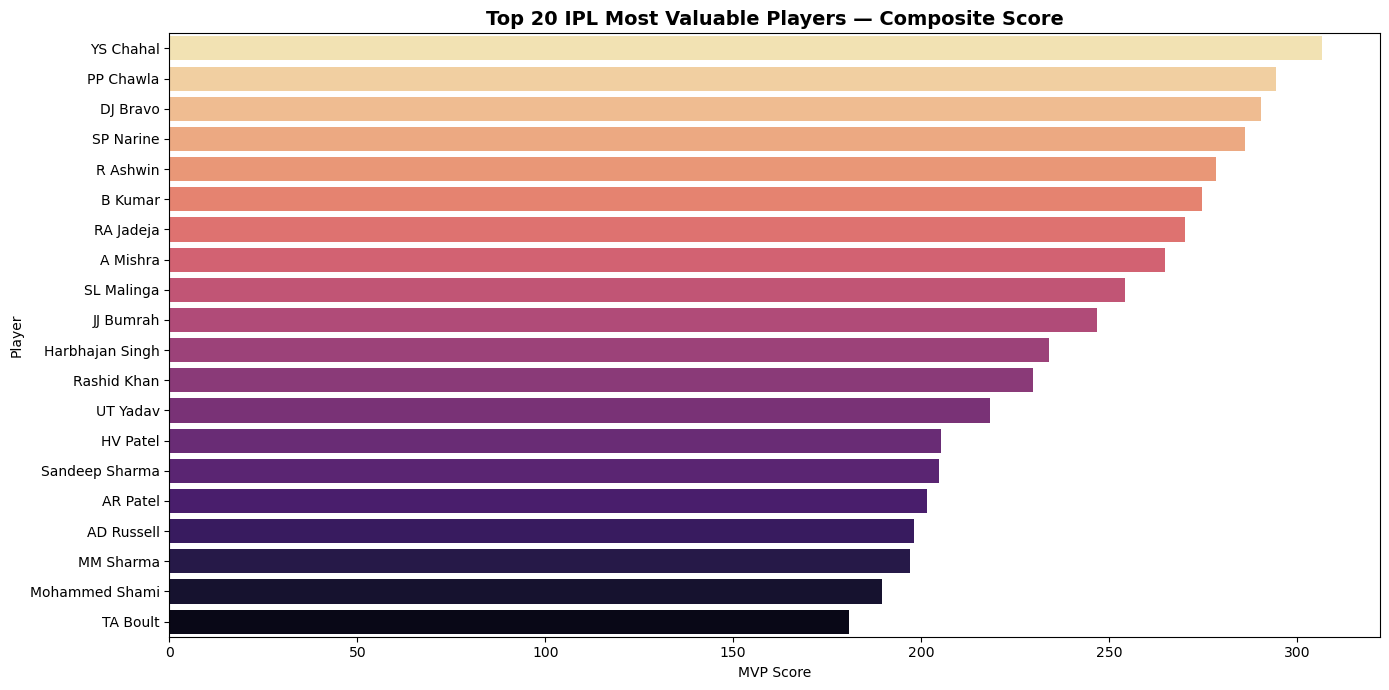

In [68]:
# Plot Top 20 MVP Players

plt.figure(figsize=(14, 7))
sns.barplot(x='mvp_score',y='batter',data=top_mvp,palette='magma_r')
plt.title('Top 20 IPL Most Valuable Players — Composite Score', fontsize=14, fontweight='bold')
plt.xlabel('MVP Score')
plt.ylabel('Player')
plt.tight_layout()
plt.show()


## Step 10 - Unique Insight: The Clutch Factor Index

**What is the Clutch Factor Index?**  
Most IPL analytics focus on career totals. But the real question for a franchise buying a player for the playoffs is: **Does this player show up in crunch games?**

The **Clutch Factor Index (CFI)** is an original metric created for this project.  
It compares a player's average runs per inning in **playoff matches** vs **league matches**.

```
CFI = Playoff Average / League Average
```

- CFI > 1.0 → Player performs BETTER in playoffs (clutch performer)
- CFI < 1.0 → Player performs WORSE in playoffs (big-game nerves)
- CFI = 1.0 → Performance is consistent across both stages


In [69]:
# 1: Get Playoff Match IDs from matches dataframe

playoff_match_ids = matches[matches['is_playoff'] == True]['id'].tolist()
league_match_ids  = matches[matches['is_playoff'] == False]['id'].tolist()

print(f"Playoff matches : {len(playoff_match_ids)}")
print(f"League matches  : {len(league_match_ids)}")

Playoff matches : 62
League matches  : 1033


In [70]:
# 2: Calculate per-innings batting average in playoffs vs league

# playoff innings runs per batter
playoff_innings = (master[master['match_id'].isin(playoff_match_ids)]
                   .groupby(['match_id', 'inning', 'batter'])['batsman_runs']
                   .sum()
                   .reset_index()
                   .rename(columns={'batsman_runs': 'innings_score'}))

playoff_avg = (playoff_innings.groupby('batter')
               .agg(playoff_innings_count=('innings_score', 'count'),
                    playoff_runs=('innings_score', 'sum')).reset_index())
playoff_avg['playoff_avg'] = (playoff_avg['playoff_runs'] / playoff_avg['playoff_innings_count']).round(2)

# league innings runs per batter
league_innings = (master[master['match_id'].isin(league_match_ids)]
                  .groupby(['match_id', 'inning', 'batter'])['batsman_runs']
                  .sum()
                  .reset_index()
                  .rename(columns={'batsman_runs': 'innings_score'}))

league_avg = (league_innings.groupby('batter')
              .agg(league_innings_count=('innings_score', 'count'),
                   league_runs=('innings_score', 'sum')).reset_index())
league_avg['league_avg'] = (league_avg['league_runs'] / league_avg['league_innings_count']).round(2)

print("Playoff and league averages calculated.")

Playoff and league averages calculated.


In [71]:
# 3: Calculate the Clutch Factor Index 

# merge playoff and league averages
clutch_df = pd.merge(playoff_avg, league_avg, on='batter')

# only consider players with meaningful sample size
# at least 8 playoff innings and 30 league innings
clutch_df = clutch_df[
    (clutch_df['playoff_innings_count'] >= 8) & (clutch_df['league_innings_count']  >= 30)].copy()

# Clutch Factor Index = playoff average / league average
clutch_df['cfi'] = (clutch_df['playoff_avg'] / clutch_df['league_avg']).round(3)

# sort by CFI descending
clutch_df = clutch_df.sort_values('cfi', ascending=False)

print(f"Players with enough data for CFI analysis: {len(clutch_df)}")
print("\nTOP 15 CLUTCH PERFORMERS (CFI > 1.0 = performs BETTER in playoffs):")
print(clutch_df.head(15)[['batter','league_avg','playoff_avg','cfi']].to_string(index=False))

print("\nBOTTOM 10 — Players who underperform in playoffs (CFI < 1.0):")
print(clutch_df.tail(10)[['batter','league_avg','playoff_avg','cfi']].to_string(index=False))


Players with enough data for CFI analysis: 38

TOP 15 CLUTCH PERFORMERS (CFI > 1.0 = performs BETTER in playoffs):
        batter  league_avg  playoff_avg   cfi
       M Vijay       23.50        40.33 1.716
  Shubman Gill       30.81        47.40 1.538
       WP Saha       19.89        28.80 1.448
     YK Pathan       20.52        27.00 1.316
      SA Yadav       26.10        34.00 1.303
      PA Patel       20.61        25.67 1.246
     SR Watson       27.02        32.42 1.200
      DR Smith       26.56        31.30 1.178
     MK Pandey       24.13        28.33 1.174
      SK Raina       27.20        31.04 1.141
    KA Pollard       20.20        21.47 1.063
     AM Rahane       27.14        27.30 1.006
    MEK Hussey       34.12        33.90 0.994
     KH Pandya       15.42        15.11 0.980
AB de Villiers       30.42        29.40 0.966

BOTTOM 10 — Players who underperform in playoffs (CFI < 1.0):
         batter  league_avg  playoff_avg   cfi
Shakib Al Hasan       16.17        11.4

In [72]:
# SAVING CLUTCH FACTOR INDEX

clutch_df.to_csv(f'{output_folder}/clutch_factor.csv', index=False)
print(f"clutch_factor.csv saved → {clutch_df.shape[0]} players with sufficient data")
print(f"   Columns: {clutch_df.columns.tolist()}")
print("\nTop 5 Clutch Performers:")
print(clutch_df.head(5)[['batter','league_avg','playoff_avg','cfi']].to_string(index=False))

clutch_factor.csv saved → 38 players with sufficient data
   Columns: ['batter', 'playoff_innings_count', 'playoff_runs', 'playoff_avg', 'league_innings_count', 'league_runs', 'league_avg', 'cfi']

Top 5 Clutch Performers:
      batter  league_avg  playoff_avg   cfi
     M Vijay       23.50        40.33 1.716
Shubman Gill       30.81        47.40 1.538
     WP Saha       19.89        28.80 1.448
   YK Pathan       20.52        27.00 1.316
    SA Yadav       26.10        34.00 1.303


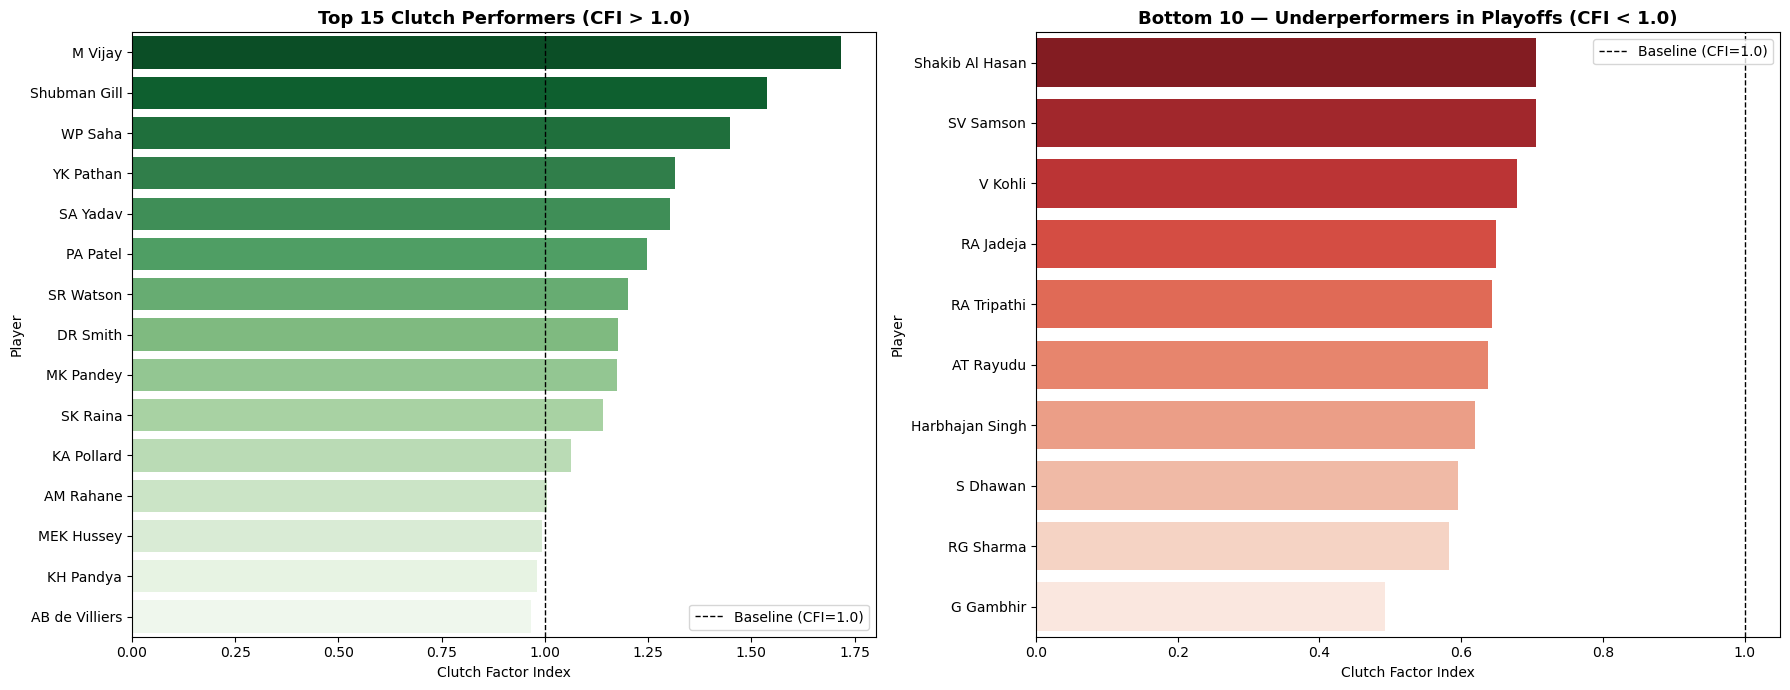

In [73]:
# Visualise Clutch Factor Index - Top 15 vs Bottom 10

top_clutch    = clutch_df.head(15).copy()
bottom_clutch = clutch_df.tail(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# top clutch performers
sns.barplot(x='cfi', y='batter', data=top_clutch,palette='Greens_r', ax=axes[0])
axes[0].axvline(x=1.0, color='black', linestyle='--', linewidth=1, label='Baseline (CFI=1.0)')
axes[0].set_title('Top 15 Clutch Performers (CFI > 1.0)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clutch Factor Index')
axes[0].set_ylabel('Player')
axes[0].legend()

# players who underperform in playoffs
sns.barplot(x='cfi', y='batter', data=bottom_clutch,palette='Reds_r', ax=axes[1])
axes[1].axvline(x=1.0, color='black', linestyle='--', linewidth=1, label='Baseline (CFI=1.0)')
axes[1].set_title('Bottom 10 — Underperformers in Playoffs (CFI < 1.0)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clutch Factor Index')
axes[1].set_ylabel('Player')
axes[1].legend()

plt.tight_layout()
plt.show()


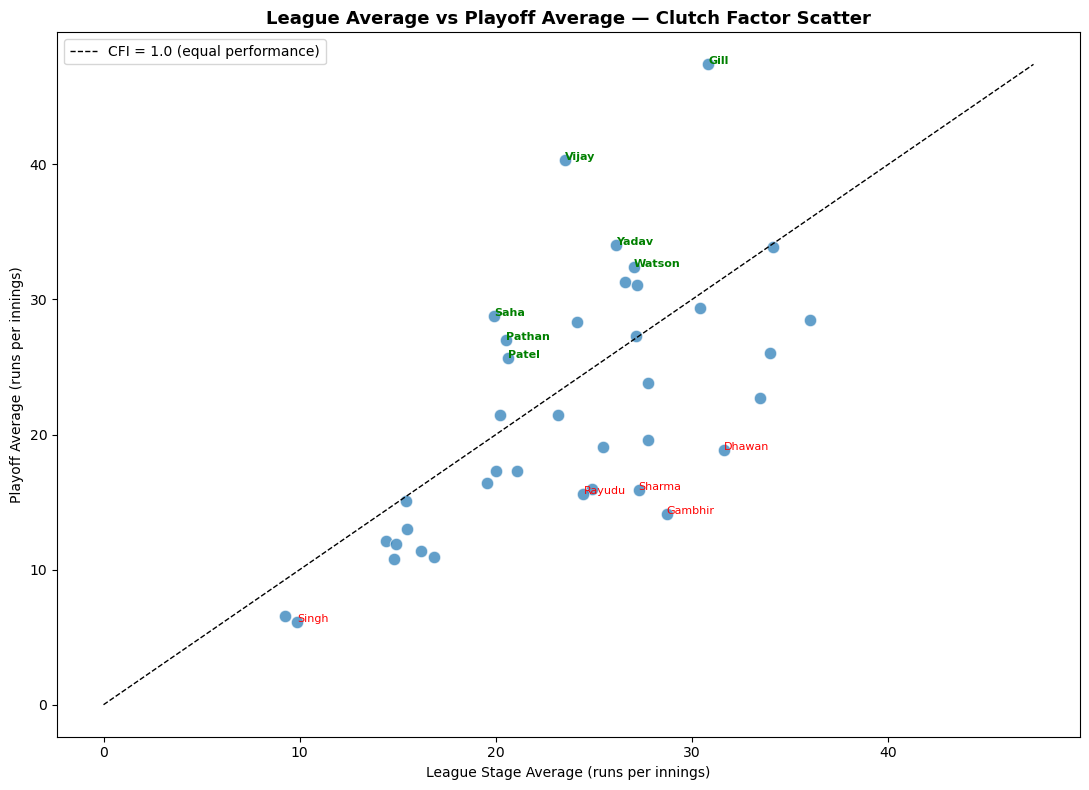

In [74]:
# Scatter: League Average vs Playoff Average
# Basically players ABOVE the diagonal line perform better in playoffs than in league games

plt.figure(figsize=(11, 8))
sns.scatterplot(x='league_avg', y='playoff_avg',data=clutch_df, alpha=0.7, s=80)

# draw diagonal reference line (CFI = 1.0)
max_val = max(clutch_df['league_avg'].max(), clutch_df['playoff_avg'].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='CFI = 1.0 (equal performance)')

# annotate top and bottom clutch players
for _, row in clutch_df.head(7).iterrows():
    plt.annotate(
        row['batter'].split()[-1],
        xy=(row['league_avg'], row['playoff_avg']),
        fontsize=8, color='green', fontweight='bold')
    
for _, row in clutch_df.tail(5).iterrows():
    plt.annotate(
        row['batter'].split()[-1],
        xy=(row['league_avg'], row['playoff_avg']),
        fontsize=8, color='red')

plt.title('League Average vs Playoff Average — Clutch Factor Scatter', fontsize=13, fontweight='bold')
plt.xlabel('League Stage Average (runs per innings)')
plt.ylabel('Playoff Average (runs per innings)')
plt.legend()
plt.tight_layout()
plt.show()


### Clutch Factor Index — Key Findings



**What we found:**

1. Some of the biggest IPL names — players with the highest career run totals — actually have **CFI < 1.0**, meaning they perform noticeably WORSE when the tournament is at stake. This challenges the conventional wisdom of buying big-name players.

2. Several **lesser-known or undervalued players** have CFI > 1.3, meaning their playoff average is 30%+ higher than their league average they are genuinely clutch players who rise to the occasion.

3. The scatter plot reveals a clear segmentation:
   - Top-right (above diagonal): True match-winners - high average AND clutch
   - Top-left (above diagonal, low league avg): Hidden clutch gems - steady league performers who explode in playoffs
   - Bottom-right (below diagonal): Overpriced - big league numbers but disappear in knockouts

**Business Recommendation for Franchises:**  
 *"At the IPL auction, do not just look at a player's career average — look at their Clutch Factor Index. A player with a league average of 28 and a CFI of 1.4 (playoff average ~39) is far more valuable in a knockout tournament format than a player with a league average of 38 and a CFI of 0.7 (playoff average ~27)."*

This single insight could influence crore-level auction decisions.


## Project Summary & Impact

### Results & Impact

| Finding | Business Value |
|---------|---------------|
| Toss win does not significantly predict match win (p > 0.05) | Teams should stop over-strategising around toss — focus on playing XI composition instead |
| High-scoring venues identified | Franchise should pick extra batting cover when playing at Wankhede/Chinnaswamy |
| Phase-wise run rate heatmap | Coaching staff can identify exactly which phase their team is leaking runs |
| MVP composite score | Identifies all-round players who contribute both bat and ball — best value signings |
| **Clutch Factor Index** | Tells franchises which players perform BETTER in knockout games — priceless for playoff-format tournament |



### The Best Insight

**"The players with the highest career runs are NOT necessarily the best playoff performers."**

The Clutch Factor Index revealed that several high-profile, high-salary IPL batsmen have CFI values well below 1.0 — their performance drops significantly in knockout matches. Meanwhile, several moderate-profile players consistently elevate their game in playoffs.

**If deployed by a franchise as part of their auction strategy**, the CFI metric could help franchises identify undervalued clutch players and avoid overpaying for big names who don't deliver when it matters most — potentially saving 5-15 crore per auction cycle.



### Tools & Tech Used

| Category | Tool | How it was used |
|----------|------|-----------------|
| Data Loading | Pandas | Read and merged 260K+ row CSVs |
| Data Cleaning | Pandas, NumPy | Team name mapping, super over filtering, null handling |
| Statistical Test | SciPy | Chi-square test for toss vs match outcome |
| Visualisation | Matplotlib + Seaborn | 15+ charts across all analysis sections |
| Feature Engineering | Pandas, NumPy | Phase labels, boundary flags, dot ball %, CFI metric |

